


**Author:** John Kitchin



## Molecules



In this chapter we consider how to construct models of molecules, how to manipulate them, and how to calculate many properties of molecules. For a nice comparison of VASP and Gaussian see citealp:paier:234102.



### Defining and visualizing molecules



We start by learning how to define a molecule and visualize it. We will begin with defining molecules from scratch, then reading molecules from data files, and finally using some built-in databases in `ase`.



#### From scratch



When there is no data file for the molecule you want, or no database to get it from, you have to define your atoms geometry by hand. Here is how that is done for a CO molecule (Figure ref:fig:co-origin). We must define the type and position of each atom, and the unit cell the atoms are in.



In [36]:
from ase import Atoms, Atom
from ase.io import write

# define an Atoms object
atoms = Atoms([Atom('C', [0., 0., 0.]),
               Atom('O', [1.1, 0., 0.])],
              cell=(10, 10, 10))

print('V = {0:1.0f} Angstrom^3'.format(atoms.get_volume()))

write('images/simple-cubic-cell.png', atoms, show_unit_cell=2)

V = 1000 Angstrom^3


    V = 1000 Angstrom^3

![img](./images/simple-cubic-cell.png "Image of a CO molecule with the C at the origin. \label{fig:co-origin}")

There are two inconvenient features of the simple cubic cell:

1.  Since the CO molecule is at the corner, its electron density is spread over the 8 corners of the box, which is not convenient for visualization later (see [BROKEN LINK: \*Visualizing%20electron%20density]).

2.  Due to the geometry of the cube, you need fairly large cubes to make sure the electron density of the molecule does not overlap with that of its images. Electron-electron interactions are repulsive, and the overlap makes the energy increase significantly. Here, the CO molecule has 6 images due to periodic boundary conditions that are 10 &Aring; away. The volume of the unit cell is 1000 &Aring;$^3$.

The first problem is easily solved by centering the atoms in the unit cell. The second problem can be solved by using a face-centered cubic lattice, which is the lattice with the closest packing. We show the results of the centering in Figure ref:fig:co-fcc, where we have guessed values for $b$ until the CO molecules are on average 10 &Aring; apart. Note the final volume is only about 715 &Aring;$^3$, which is smaller than the cube. This will result in less computational time to compute properties.



In [37]:
from ase import Atoms, Atom
from ase.io import write

b = 7.1
atoms = Atoms([Atom('C', [0., 0., 0.]),
               Atom('O', [1.1, 0., 0.])],
              cell=[[b, b, 0.],
                    [b, 0., b],
                    [0., b, b]])

print('V = {0:1.0f} Ang^3'.format(atoms.get_volume()))

atoms.center()  # translate atoms to center of unit cell
write('images/fcc-cell.png', atoms, show_unit_cell=2)

V = 716 Ang^3


    V = 716 Ang^3

![img](./images/fcc-cell.png "CO in a face-centered cubic unit cell. \label{fig:co-fcc}")

At this point you might ask, "How do you know the distance to the neighboring image?" The `ag` viewer lets you compute this graphically, but we can use code to determine this too. All we have to do is figure out the length of each lattice vector, because these are what separate the atoms in the images. We use the mod:numpy module to compute the distance of a vector as the square root of the sum of squared elements.



In [38]:
from ase import Atoms, Atom
import numpy as np

b = 7.1
atoms = Atoms([Atom('C', [0., 0., 0.]),
               Atom('O', [1.1, 0., 0.])],
              cell=[[b, b, 0.],
                    [b, 0., b],
                    [0., b, b]])

# get unit cell vectors and their lengths
(a1, a2, a3) = atoms.get_cell()
print('|a1| = {0:1.2f} Ang'.format(np.sum(a1**2)**0.5))
print('|a2| = {0:1.2f} Ang'.format(np.linalg.norm(a2)))
print('|a3| = {0:1.2f} Ang'.format(np.sum(a3**2)**0.5))

|a1| = 10.04 Ang
|a2| = 10.04 Ang
|a3| = 10.04 Ang


    |a1| = 10.04 Ang
    |a2| = 10.04 Ang
    |a3| = 10.04 Ang



#### Reading other data formats into a calculation



mod:ase.io.read supports many different file formats:

    Known formats:
    
    =========================  ===========
    format                     short name
    =========================  ===========
    GPAW restart-file          gpw
    Dacapo netCDF output file  dacapo
    Old ASE netCDF trajectory  nc
    Virtual Nano Lab file      vnl
    ASE pickle trajectory      traj
    ASE bundle trajectory      bundle
    GPAW text output           gpaw-text
    CUBE file                  cube
    XCrySDen Structure File    xsf
    Dacapo text output         dacapo-text
    XYZ-file                   xyz
    VASP POSCAR/CONTCAR file   vasp
    VASP OUTCAR file           vasp_out
    SIESTA STRUCT file         struct_out
    ABINIT input file          abinit
    V_Sim ascii file           v_sim
    Protein Data Bank          pdb
    CIF-file                   cif
    FHI-aims geometry file     aims
    FHI-aims output file       aims_out
    VTK XML Image Data         vti
    VTK XML Structured Grid    vts
    VTK XML Unstructured Grid  vtu
    TURBOMOLE coord file       tmol
    TURBOMOLE gradient file    tmol-gradient
    exciting input             exi
    AtomEye configuration      cfg
    WIEN2k structure file      struct
    DftbPlus input file        dftb
    CASTEP geom file           cell
    CASTEP output file         castep
    CASTEP trajectory file     geom
    ETSF format                etsf.nc
    DFTBPlus GEN format        gen
    CMR db/cmr-file            db
    CMR db/cmr-file            cmr
    LAMMPS dump file           lammps
    Gromacs coordinates        gro
    =========================  ===========

You can read XYZ file format to create mod:ase.Atoms objects.  Here is
what an XYZ file format might look like:

    #+include: molecules/isobutane.xyz

The first line is the number of atoms in the file. The second line is
often a comment. What follows is one line per atom with the symbol and
Cartesian coordinates in &Aring;. Note that the XYZ format does not have
unit cell information in it, so you will have to figure out a way to
provide it. In this example, we center the atoms in a box with vacuum
on all sides (Figure ref:fig:isobutane).



In [39]:
from ase.io import read, write

atoms = read('../molecules/isobutane.xyz')
atoms.center(vacuum=5)
write('images/isobutane-xyz.png', atoms, show_unit_cell=2)

![img](./images/isobutane-xyz.png "An isobutane molecule read in from an XYZ formatted data file. \label{fig:isobutane}")



#### Predefined molecules



mod:ase defines a number of molecular geometries in the
mod:ase.data.molecules database.  For example, the database includes
the molecules in the G2/97 database cite:curtiss:1063. This database
contains a broad set of atoms and molecules for which good
experimental data exists, making them useful for benchmarking studies.
See [this site](http://www.cse.anl.gov/OldCHMwebsiteContent/compmat/comptherm.htm) for the original files.

The coordinates for the atoms in the database are [MP2](http://en.wikipedia.org/wiki/M%C3%B8ller-Plesset_perturbation_theory)(full)/[6-31G(d)](http://en.wikipedia.org/wiki/Basis_set_%28chemistry%29)
optimized geometries. Here is a list of all the species available in
mod:ase.data.g2. You may be interested in reading about some of the other databases in mod:ase.data too.



In [40]:
from ase.data import g2
keys = list(g2.data.keys())
# print in 3 columns
for i in range(len(keys) // 3):
    print('{0:25s}{1:25s}{2:25s}'.format(*tuple(keys[i * 3: i * 3 + 3])))

Be                       BeH                      C                        
C2H2                     C2H4                     C2H6                     
CH                       CH2_s1A1d                CH2_s3B1d                
CH3                      CH3Cl                    CH3OH                    
CH3SH                    CH4                      CN                       
CO                       CO2                      CS                       
Cl                       Cl2                      ClF                      
ClO                      F                        F2                       
H                        H2CO                     H2O                      
H2O2                     HCN                      HCO                      
HCl                      HF                       HOCl                     
Li                       Li2                      LiF                      
LiH                      N                        N2                       
N2H4        

Some other databases include the mod:ase.data.s22 for weakly interacting dimers and complexes, and mod:ase.data.extra<sub>molecules</sub> which has a few extras like biphenyl and C60.

Here is an example of getting the geometry of an acetonitrile molecule and writing an image to a file. Note that the default unit cell is a 1 Å × Å × Å  cubic cell. That is too small to use if your calculator uses periodic boundary conditions. We center the atoms in the unit cell and add vacuum on each side. We will add 6 Å of vacuum on each side. In the write command we use the option `show_unit_cell` =2 to draw the unit cell boundaries. See Figure ref:fig:ch3cn.



In [41]:
from ase.build import molecule
from ase.io import write


atoms = molecule('CH3CN')

atoms.center(vacuum=6)
print('unit cell')
print('---------')
print(atoms.get_cell())

write('images/ch3cn.png', atoms, show_unit_cell=2)

unit cell
---------
Cell([13.775328, 13.537479, 15.014576])


In [42]:
from ase.build import molecule
from ase.io import write

atoms = molecule('CH3CN')

atoms.center(vacuum=6)
print('unit cell')
print('---------')
print(atoms.get_cell())

write('images/ch3cn-rotated.png', atoms,
      show_unit_cell=2, rotation='45x,45y,0z')

unit cell
---------
Cell([13.775328, 13.537479, 15.014576])


In [43]:
from ase.build import molecule
from ase.io import write
from numpy import pi

atoms = molecule('CH3CN')
atoms.center(vacuum=6)
p1 = atoms.get_positions()

atoms.rotate('x', pi/4, center='COM', rotate_cell=False)
atoms.rotate('y', pi/4, center='COM', rotate_cell=False)

write('images/ch3cn-rotated-2.png', atoms, show_unit_cell=2)
print('difference in positions after rotating')
print('atom    difference vector')
print('--------------------------------------')
p2 = atoms.get_positions()

diff = p2 - p1
for i, d in enumerate(diff):
    print('{0} {1}'.format(i, d))

difference in positions after rotating
atom    difference vector
--------------------------------------
0 [-0.018  0.018  0.   ]
1 [ 0.002 -0.002 -0.   ]
2 [ 0.018 -0.018 -0.   ]
3 [-0.023  0.023  0.014]
4 [-0.023  0.023 -0.019]
5 [-0.023  0.023  0.005]


#### Combining Atoms objects



It is frequently useful to combine two `Atoms` objects, e.g. for computing reaction barriers, or other types of interactions. In `ase`, we simply add two `Atoms` objects together. Here is an example of getting an ammonia and oxygen molecule in the same unit cell. See Figure ref:fig:combined-atoms. We set the `Atoms` about three &Aring; apart using the func:ase.Atoms.translate function.



In [44]:
from ase.build import molecule
from ase.io import write

atoms1 = molecule('NH3')

atoms2 = molecule('O2')
atoms2.translate([3, 0, 0])

bothatoms = atoms1 + atoms2
bothatoms.center(5)

write('images/bothatoms.png', bothatoms, show_unit_cell=2, rotation='90x')

![img](./images/bothatoms.png "Image featuring ammonia and oxygen molecule in one unit cell. \label{fig:combined-atoms}")



### Simple properties



Simple properties do not require a DFT calculation. They are typically only functions of the atom types and geometries.



#### Getting cartesian positions



If you want the $(x,y,z)$ coordinates of the atoms, use the func:ase.Atoms.get<sub>positions</sub>. If you are interested in the fractional coordinates, use func:ase.Atoms.get<sub>scaled</sub><sub>positions</sub>.



In [45]:
from ase.build import molecule

atoms = molecule('C6H6')  # benzene

# access properties on each atom
print(' #  sym   p_x     p_y     p_z')
print('------------------------------')
for i, atom in enumerate(atoms):
   print('{0:3d}{1:^4s}{2:-8.2f}{3:-8.2f}{4:-8.2f}'.format(i,
                                                           atom.symbol,
                                                           atom.x,
                                                           atom.y,
                                                           atom.z))

# get all properties in arrays
sym = atoms.get_chemical_symbols()
pos = atoms.get_positions()
num = atoms.get_atomic_numbers()

atom_indices = range(len(atoms))

print()
print('  # sym    at#    p_x     p_y     p_z')
print('-------------------------------------')
for i, s, n, p in zip(atom_indices, sym, num, pos):
    px, py, pz = p
    print('{0:3d}{1:>3s}{2:8d}{3:-8.2f}{4:-8.2f}{5:-8.2f}'.format(i, s, n,
                                                                  px, py, pz))

 #  sym   p_x     p_y     p_z
------------------------------
  0 C      0.00    1.40    0.00
  1 C      1.21    0.70    0.00
  2 C      1.21   -0.70    0.00
  3 C      0.00   -1.40    0.00
  4 C     -1.21   -0.70    0.00
  5 C     -1.21    0.70    0.00
  6 H      0.00    2.48    0.00
  7 H      2.15    1.24    0.00
  8 H      2.15   -1.24    0.00
  9 H      0.00   -2.48    0.00
 10 H     -2.15   -1.24    0.00
 11 H     -2.15    1.24    0.00

  # sym    at#    p_x     p_y     p_z
-------------------------------------
  0  C       6    0.00    1.40    0.00
  1  C       6    1.21    0.70    0.00
  2  C       6    1.21   -0.70    0.00
  3  C       6    0.00   -1.40    0.00
  4  C       6   -1.21   -0.70    0.00
  5  C       6   -1.21    0.70    0.00
  6  H       1    0.00    2.48    0.00
  7  H       1    2.15    1.24    0.00
  8  H       1    2.15   -1.24    0.00
  9  H       1    0.00   -2.48    0.00
 10  H       1   -2.15   -1.24    0.00
 11  H       1   -2.15    1.24    0.00


#### Molecular weight and molecular formula



We can quickly compute the molecular weight of a molecule with this recipe. We use func:ase.Atoms.get<sub>masses</sub> to get an array of the atomic masses of each atom in the `Atoms` object, and then just sum them up.



In [46]:
from ase.build import molecule

atoms = molecule('C6H6')
masses = atoms.get_masses()

molecular_weight = masses.sum()
molecular_formula = atoms.get_chemical_formula(mode='reduce')

# note use of two lines to keep length of line reasonable
s = 'The molecular weight of {0} is {1:1.2f} gm/mol'
print(s.format(molecular_formula, molecular_weight))

The molecular weight of C6H6 is 78.11 gm/mol


Note that the argument `reduce=True` for func:ase.Atoms.get<sub>chemical</sub><sub>formula</sub> collects all the symbols to provide a molecular formula.



#### Center of mass



The center of mass (COM) is defined as:

COM = $\frac{\sum m_i \cdot r_i}{\sum m_i}$

The center of mass is essentially the average position of the atoms, weighted by the mass of each atom. Here is an example of getting the center of mass from an `Atoms` object using func:ase.Atoms.get<sub>center</sub><sub>of</sub><sub>mass</sub>.



In [47]:
from ase.build import molecule
import numpy as np

# ammonia
atoms = molecule('NH3')

  # cartesian coordinates
print('COM1 = {0}'.format(atoms.get_center_of_mass()))

# compute the center of mass by hand
pos = atoms.positions
masses = atoms.get_masses()

COM = np.array([0., 0., 0.])
for m, p in zip(masses, pos):
    COM += m*p
COM /= masses.sum()

print('COM2 = {0}'.format(COM))

# one-line linear algebra definition of COM
print('COM3 = {0}'.format(np.dot(masses, pos) / np.sum(masses)))

COM1 = [0.    0.    0.048]
COM2 = [0.    0.    0.048]
COM3 = [0.    0.    0.048]


You can see see that these centers of mass, which are calculated by different methods, are the same.



#### Moments of inertia



The [moment of inertia](http://en.wikipedia.org/wiki/Moment_of_inertia) is a measure of resistance to changes in rotation. It is defined by $I = \sum_{i=1}^N m_i r_i^2$ where $r_i$ is the distance to an axis of rotation. There are typically three moments of inertia, although some may be zero depending on symmetry, and others may be degenerate. There is a convenient function to get the  moments of inertia: func:ase.Atoms.get<sub>moments</sub><sub>of</sub><sub>inertia</sub>. Here are several examples of molecules with different types of symmetry.:



In [48]:
from ase.build import molecule

print('linear rotors: I = [0 Ia Ia]')
atoms = molecule('CO2')
print('  CO2 moments of inertia: {}'.format(atoms.get_moments_of_inertia()))
print('')

print('symmetric rotors (Ia = Ib) < Ic')
atoms = molecule('NH3')
print('  NH3 moments of inertia: {}'.format(atoms.get_moments_of_inertia()))

atoms = molecule('C6H6')
print('  C6H6 moments of inertia: {}'.format(atoms.get_moments_of_inertia()))
print('')

print('symmetric rotors Ia < (Ib = Ic)')
atoms = molecule('CH3Cl')
print('CH3Cl moments of inertia: {}'.format(atoms.get_moments_of_inertia()))
print('')

print('spherical rotors Ia = Ib = Ic')
atoms = molecule('CH4')
print('  CH4 moments of inertia: {}'.format(atoms.get_moments_of_inertia()))
print('')

print('unsymmetric rotors Ia != Ib != Ic')
atoms = molecule('C3H7Cl')
print('  C3H7Cl moments of inertia: {}'.format(atoms.get_moments_of_inertia()))

linear rotors: I = [0 Ia Ia]
  CO2 moments of inertia: [ 0.    44.453 44.453]

symmetric rotors (Ia = Ib) < Ic
  NH3 moments of inertia: [1.71 1.71 2.67]
  C6H6 moments of inertia: [ 88.78   88.78  177.561]

symmetric rotors Ia < (Ib = Ic)
CH3Cl moments of inertia: [ 3.204 37.97  37.97 ]

spherical rotors Ia = Ib = Ic
  CH4 moments of inertia: [3.192 3.192 3.192]

unsymmetric rotors Ia != Ib != Ic
  C3H7Cl moments of inertia: [ 19.414 213.185 223.158]


If you want to know the principle axes of rotation, we simply pass `vectors=True` to the function, and it returns the moments of inertia and the principle axes.



In [49]:
from ase.build import molecule

atoms = molecule('CH3Cl')
moments, axes = atoms.get_moments_of_inertia(vectors=True)
print('Moments = {0}'.format(moments))
print('axes = {0}'.format(axes))

Moments = [ 3.204 37.97  37.97 ]
axes = [[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


This shows the first moment is about the z-axis, the second moment is about the y-axis, and the third moment is about the x-axis.



#### Computing bond lengths and angles



A typical question we might ask is, "What is the structure of a molecule?" In other words, what are the bond lengths, angles between bonds, and similar properties. The Atoms object contains an `ase.Atoms.get_distance` method to make this easy. To calculate the distance between two atoms, you have to specify their indices, remembering that the index starts at 0.



In [50]:
from ase.build import molecule

# ammonia
atoms = molecule('NH3')

print('atom symbol')
print('===========')
for i, atom in enumerate(atoms):
    print('{0:2d} {1:3s}' .format(i, atom.symbol))

# N-H bond length
s = 'The N-H distance is {0:1.3f} angstroms'
print(s.format(atoms.get_distance(0, 1)))

atom symbol
 0 N  
 1 H  
 2 H  
 3 H  
The N-H distance is 1.017 angstroms


Bond angles are a little trickier. If we had vectors describing the directions between two atoms, we could use some simple trigonometry to compute the angle between the vectors: $\vec{a} \cdot \vec{b} = |\vec{a}||\vec{b}| \cos(\theta)$.  So we can calculate the angle as $\theta = \arccos\left(\frac{\vec{a} \cdot \vec{b}}{|\vec{a}||\vec{b}|}\right)$, we just have to define our two vectors $\vec{a}$ and $\vec{b}$. We compute these vectors as the difference in positions of two atoms. For example, here we compute the angle H-N-H in an ammonia molecule. This is the angle between N-H$_1$ and N-H$_2$. In the next example, we utilize functions in mod:numpy to perform the calculations, specifically the func:numpy.arccos function, the func:numpy.dot function, and func:numpy.linalg.norm functions.



In [51]:
from ase.build import molecule

# ammonia
atoms = molecule('NH3')

print('atom symbol')
print('===========')
for i, atom in enumerate(atoms):
    print('{0:2d} {1:3s}'.format(i, atom.symbol))

a = atoms.positions[0] - atoms.positions[1]
b = atoms.positions[0] - atoms.positions[2]

from numpy import arccos, dot, pi
from numpy.linalg import norm

theta_rad = arccos(dot(a, b) / (norm(a) * norm(b)))  # in radians

print('theta = {0:1.1f} degrees'.format(theta_rad * 180./pi))

atom symbol
 0 N  
 1 H  
 2 H  
 3 H  
theta = 106.3 degrees


In [52]:
from ase.build import molecule
from numpy import pi
# ammonia
atoms = molecule('NH3')

print('theta = {0} degrees'.format(atoms.get_angle(1, 0, 2)))

theta = 106.33462423179175 degrees


##### Dihedral angles



There is support in ase for computing [dihedral angles](http://en.wikipedia.org/wiki/Dihedral_angle). Let us illustrate that for ethane. We will compute the dihedral angle between atoms 5, 1, 0, and 4. That is a H-C-C-H dihedral angle, and one can visually see (although not here) that these atoms have a dihedral angle of 60<sup>&deg;</sup> (Figure ref:fig:ethane-dihedral).



In [53]:
# calculate an ethane dihedral angle
from ase.build import molecule
import numpy as np

atoms = molecule('C2H6')

print('atom symbol')
print('===========')
for i, atom in enumerate(atoms):
    print('{0}    {1}'.format(i, atom.symbol))

# compute the dihedral angle
dihedral = atoms.get_dihedral(4, 0, 1, 5)
print('')
print('Dihedral angle (4, 0, 1, 5) = {0:1.0f} degrees'.format(dihedral))

atom symbol
0    C
1    C
2    H
3    H
4    H
5    H
6    H
7    H

Dihedral angle (4, 0, 1, 5) = 60 degrees


![img](./images/ethane-dihedral.png "Schematic of the calculated ethane dihedral angle. \label{fig:ethane-dihedral}")
In this section we covered properties that require simple calculations, but not DFT calculations, to compute.



### Simple properties that require single computations



There are many properties that only require a single DFT calculation to obtain the energy, forces, density of states, electron density and electrostatic potential. This section describes some of these calculations and their analysis.



#### Energy and forces



Two of the most important quantities we are interested in are the total
energy and the forces on the atoms. To get these quantities, we have
to define a calculator and attach it to an mod:ase.Atoms object so
that `ase` knows how to get the data. After defining the calculator a
DFT calculation must be run.

Here is an example of getting the energy and forces from a CO
molecule. The forces in this case are very high, indicating that this
geometry is not close to the ground state geometry. Note that the
forces are only along the $x$-axis, which is along the molecular axis. We will see how to minimize this force later.
<div class="note" id="org8e4d957">
<p>
This is your first DFT calculation in the book! 
</p>

</div>



In [54]:
from ase import Atoms, Atom
from vasp import Vasp

co = Atoms([Atom('C', [0, 0, 0]),
            Atom('O', [1.2, 0, 0])],
           cell=(6., 6., 6.))

calc = Vasp(label='molecules/simple-co',  # output dir
            xc='pbe',  # the exchange-correlation functional
            nbands=6,    # number of bands
            encut=350,    # planewave cutoff
            ismear=1,    # Methfessel-Paxton smearing
            sigma=0.01,  # very small smearing factor for a molecule
            atoms=co)

print('energy = {0} eV'.format(co.get_potential_energy()))
print(co.get_forces())

energy = -14.69072754 eV
[[ 5.091  0.    -0.   ]
 [-5.091 -0.     0.   ]]


We can see what files were created and used in this calculation by printing the vasp attribute of the calculator.



In [55]:
from vasp import Vasp
calc = Vasp(label='molecules/simple-co')
# Check if calculation directory exists
import os
print(os.path.exists('molecules/simple-co'))

True


##### Convergence with unit cell size



There are a number of parameters that affect the energy and forces including the calculation parameters and the unit cell. We will first consider the effect of the unit cell on the total energy and forces. The reason that the unit cell affects the total energy is that it can change the distribution of electrons in the molecule.



In [56]:
from vasp import Vasp
from ase import Atoms, Atom
import numpy as np
np.set_printoptions(precision=3, suppress=True)

atoms = Atoms([Atom('C', [0, 0, 0]),
               Atom('O', [1.2, 0, 0])])

L = [4, 5, 6, 8, 10]

for a in L:
    atoms.set_cell([a, a, a], scale_atoms=False)
    atoms.center()
    calc = Vasp(label='molecules/co-L-{0}'.format(a),
                xc='PBE',
                encut=350,
                atoms=atoms)
    try:
        atoms_out = calc.get_atoms()
        print('{0} {1}'.format(a, atoms_out.get_potential_energy()))
    except Exception as e:
        print('{0} not ready: {1}'.format(a, e))

4 -15.35943421
5 -14.85641879
6 -14.68750603
8 -14.63193135
10 -14.65343306


Here there are evidently attractive interactions between the CO molecules which lower the total energy for small box sizes. We have to decide what an appropriate volume for our calculation is, and the choice depends on the goal. We may wish to know the total energy of a molecule that is not interacting with any other molecules, e.g. in the ideal gas limit. In that case we need a large unit cell so the electron density from the molecule does not go outside the unit cell where it would overlap with neighboring images.

It pays to check for convergence. The cost of running the calculation goes up steeply with increasing cell size. Doubling a lattice vector here leads to a 20-fold increase in computational time! Note that doubling a lattice vector length increases the volume by a factor of 8 for a cube. The cost goes up because the number of planewaves that fit in the cube grows as the cube gets larger.



In [57]:
from vasp import Vasp
import os

L = [4, 5, 6, 8, 10]

for a in L:
    directory = 'molecules/co-L-{0}'.format(a)
    if os.path.exists(os.path.join(directory, 'OUTCAR')):
        print('{0} calculation exists'.format(a))
    else:
        print('{0} not found'.format(a))

4 calculation exists
5 calculation exists
6 calculation exists
8 calculation exists
10 calculation exists


Let us consider what the pressure in the unit cell is. In the ideal gas limit we have $PV = nRT$, which gives a pressure of zero at absolute zero. At non-zero temperatures, we have $P=n/V RT$. Let us consider some examples. In atomic units we use $k_B$ instead of $R$.



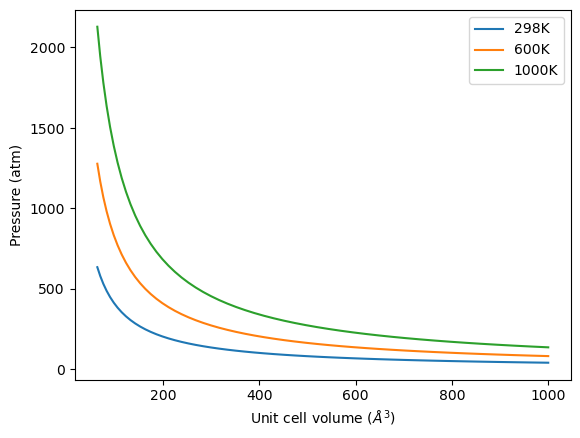

In [58]:
from ase.units import kB, Pascal
import numpy as np
import matplotlib.pyplot as plt

atm = 101325 * Pascal

L = np.linspace(4, 10)
V = L**3

n = 1  # one atom/molecule per unit cell

for T in [298, 600, 1000]:
    P = n / V * kB * T / atm  # convert to atmospheres

    plt.plot(V, P, label='{0}K'.format(T))

plt.xlabel('Unit cell volume ($\AA^3$)')
plt.ylabel('Pressure (atm)')
plt.legend(loc='best');

##### Convergence of ENCUT



The total energy and forces also depend on the computational parameters, notably incar:ENCUT.



In [59]:
from ase import Atoms, Atom
from vasp import Vasp
import numpy as np
np.set_printoptions(precision=3, suppress=True)

atoms = Atoms([Atom('C', [0, 0, 0]),
               Atom('O', [1.2, 0, 0])],
              cell = (6, 6, 6))
atoms.center()

calc = Vasp(label='molecules/simple-co',
            xc='PBE',
            encut=350,
            atoms=atoms)

try:
    atoms = calc.get_atoms()
    print('potential energy = {0} eV'.format(atoms.get_potential_energy()))
    print('forces (eV/Ang):')
    print(atoms.get_forces())
except Exception as e:
    print('Calculation not ready: {}'.format(e))

potential energy = -14.69072754 eV
forces (eV/Ang):
[[ 5.091  0.    -0.   ]
 [-5.091 -0.     0.   ]]


##### Cloning



You may want to clone a calculation, so you can change some parameter without losing the previous result. The clone function does this, and changes the calculator over to the new directory.



In [60]:
from ase import Atoms, Atom
from vasp import Vasp
import os
import shutil

calc = Vasp(label='molecules/simple-co')
try:
    print('energy = {0} eV'.format(calc.get_atoms().get_potential_energy()))
except:
    print('Calculation not ready')

# Copy directory instead of clone (clone is deprecated)
src = 'molecules/simple-co'
dst = 'molecules/simple-co-copy'
if os.path.exists(src) and not os.path.exists(dst):
    shutil.copytree(src, dst)
    print('Copied {} to {}'.format(src, dst))
elif os.path.exists(dst):
    print('Destination {} already exists'.format(dst))
else:
    print('Source {} does not exist'.format(src))

Calculation not ready
Destination molecules/simple-co-copy already exists


#### Visualizing electron density



The electron density is a 3$d$ quantity: for every $(x,y,z)$ point, there is a charge density. That means we need 4 numbers for each point: $(x,y,z)$ and $\rho(x,y,z)$. Below we show an example (Figure ref:fig:cd1) of plotting the charge density, and we consider some issues we have to consider when visualizing volumetric data in unit cells with periodic boundary conditions. We will use the results from a previous calculation.



In [61]:
from vasp import Vasp
from ase.visualize import view
from ase.io import write

calc = Vasp(label='molecules/simple-co')
try:
    atoms = calc.get_atoms()
    # Save as image instead of 3D visualization
    write('images/co-structure.png', atoms, show_unit_cell=2)
    print('Structure saved to images/co-structure.png')
except Exception as e:
    print('Calculation not ready: {}'.format(e))

Calculation not ready: Calculator has no atoms


If we take care to center the CO molecule in the unit cell, we get a nicer looking result.



In [62]:
from vasp import Vasp
from ase.visualize import view
from ase.io import write
from ase import Atom, Atoms

atoms = Atoms([Atom('C', [2.422, 0.0, 0.0]),
               Atom('O', [3.634, 0.0, 0.0])],
              cell=[6.0, 6.0, 6.0])

# Save as image instead of 3D visualization
write('images/co-atoms.png', atoms, show_unit_cell=2)
print('Structure saved to images/co-atoms.png')

Structure saved to images/co-atoms.png


![img](./images/co-centered-cd.png "Charge density of a CO molecule centered in the unit cell. Now the electron density is centered in the unit cell. \label{fig:cd2}")

TODO: how to make this figure ![img](http://www.zid.tuwien.ac.at/fileadmin/files_zid/zidline/images/zl22/vasp--fig1.jpg)



#### Visualizing electron density differences



Here, we visualize how charge moves in a benzene ring when you substitute an H atom with an electronegative Cl atom.



In [63]:
#!/usr/bin/env python
from ase import Atoms
from ase.build import molecule
from vasp import Vasp
from ase.io import write

### Setup calculators
benzene = molecule('C6H6')
benzene.set_cell([10, 10, 10])
benzene.center()

calc = Vasp(label='molecules/benzene-chg',
            xc='PBE',
            encut=350,
            lcharg=True,
            atoms=benzene)

try:
    atoms = calc.get_atoms()
    write('images/benzene.png', atoms, show_unit_cell=2)
    print('Structure saved to images/benzene.png')
except Exception as e:
    print('Calculation not ready: {}'.format(e))

Structure saved to images/benzene.png


![img](./images/benzene.png)



#### Dipole moments



The [dipole moment](http://en.wikipedia.org/wiki/Molecular_dipole_moment#Molecular_dipoles) is a vector describing the separation of  electrical (negative) and nuclear (positive) charge. The magnitude of this vector is the dipole moment, which has units of Coulomb-meter, or more commonly Debye. The symmetry of a molecule determines if a molecule has a dipole moment or not. Below we compute the dipole moment of CO. We must integrate the electron density to find the center of electrical charge, and compute a sum over the nuclei to find the center of positive charge.



In [64]:
from vasp import Vasp
import numpy as np
from ase.units import Debye
import os

calc = Vasp(label='molecules/co-centered')
try:
    atoms = calc.get_atoms()
    # Note: charge density analysis requires additional tools
    # The vasp.charge_density module has been deprecated
    print('Calculation directory: molecules/co-centered')
    print('To analyze charge density, use external tools like VESTA')
except Exception as e:
    print('Calculation not ready: {}'.format(e))

Calculation not ready: Calculator has no atoms


Note that a function using the code above exists in `vasp` which makes it trivial to compute the dipole moment. Here is an example of its usage.



In [65]:
from vasp import Vasp
from ase.units import Debye

calc = Vasp(label='molecules/co-centered')

dipole_moment = calc.get_dipole_moment()
print('The dipole moment is {0:1.2f} Debye'.format(dipole_moment))

ValueError: No atoms specified for calculation.

Atoms must be provided either:
  1. At initialization: calc = Vasp('dir', atoms=atoms, ...)
  2. As a property: calc.atoms = atoms
  3. When calling write_input: calc.write_input(atoms=atoms)

Example:
  from ase.build import bulk
  atoms = bulk('Si')
  calc = Vasp('si-calc', atoms=atoms, xc='PBE')


#### The density of states (DOS)



The density of states (DOS) gives you the number of electronic states (i.e., the orbitals) that have a particular energy. We can get this information from the last calculation we just ran without having to run another DFT calculation.



In [ ]:
from vasp import Vasp
from ase.dft.dos import DOS
import matplotlib.pyplot as plt

calc = Vasp(label='molecules/simple-co')   # we already ran this!
dos = DOS(calc)
plt.plot(dos.get_energies(), dos.get_dos())
plt.xlabel('Energy - $E_f$ (eV)')
plt.ylabel('DOS');

#### Atom-projected density of states on molecules



Let us consider which states in the density of states belong to which atoms in a molecule. This can only be a qualitative consideration because the orbitals on the atoms often hybridize to form molecular orbitals, e.g. in methane the $s$ and $p$ orbitals can form what we call $sp^3$ orbitals. We can compute atom-projected density of states in VASP, which is done by projecting the wave function onto localized atomic orbitals. Here is an example. We will consider the CO molecule. To get atom-projected density of states, we must set RWIGS for each atom. This parameter defines the radius of the sphere around the atom which cuts off the projection. The total density of states and projected density of states information comes from the DOSCAR file.

Note that unlike the DOS, here we must run another calculation because we did not specify the atom-projected keywords above. Our strategy is to get the atoms from the previous calculation, and use them in a new calculation. You could redo the calculation in the same directory, but you risk losing the results of the first step. That can make it difficult to reproduce a result. We advocate our approach of using multiple directories for the subsequent calculations, because it leaves a clear trail of how the work was done.

<p>
The RWIGS is not uniquely determined for an element. There are various natural choices, e.g. the ionic radius of an atom, or a value that minimizes overlap of neighboring spheres, but these values can change slightly in different environments.
</p>

<p>
You can also get spin-polarized atom-projected DOS, and magnetization projected DOS. See [VASP DOSCAR documentation](http://cms.mpi.univie.ac.at/vasp/vasp/DOSCAR_file.html#doscar)for more details.
</p>



In [ ]:
from vasp import Vasp
from ase.dft.dos import DOS
import matplotlib.pyplot as plt

# get the geometry from another calculation
calc = Vasp(label='molecules/simple-co')
try:
    atoms = calc.get_atoms()
    
    calc2 = Vasp(label='molecules/co-dos',
                 xc='PBE',
                 encut=350,
                 ismear=-5,  # tetrahedron with blochl
                 atoms=atoms)
    
    atoms2 = calc2.get_atoms()
    dos = DOS(calc2, width=0.2)
    d = dos.get_dos()
    e = dos.get_energies()
    
    plt.figure()
    plt.plot(e, d)
    plt.xlabel('Energy (eV)')
    plt.ylabel('DOS')
    plt.show()
except Exception as e:
    print('Calculation not ready: {}'.format(e))

#### Electrostatic potential



This is an example of the so-called &sigma; hole in a [halogen bond](http://pubs.acs.org/cen/science/87/8738sci2.html). The coordinates for the CF<sub>3</sub>Br molecule were found at [http://cccbdb.nist.gov/exp2.asp?casno=75638](http://cccbdb.nist.gov/exp2.asp?casno=75638).



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms
from ase.io import write

atoms = Atoms([Atom('C', [5., 5., 5.]),
               Atom('O', [6.1, 5., 5.])],
              cell=(10, 10, 10))

write('images/co-elf.png', atoms, show_unit_cell=2)
print('Structure saved to images/co-elf.png')

#### Bader analysis



index:bader

Note: Thanks to @prtkm for helping improve this section ([https://github.com/jkitchin/dft-book/issues/2](https://github.com/jkitchin/dft-book/issues/2)).
Bader analysis is a charge partitioning scheme where charge is divided by surfaces of zero flux that define atomic basins of charge. The most modern way of calculating the Bader charges is using the `bader` program from Graeme Henkelmen's group cite:Henkelman2006354,doi.10.1021/ct100125x. Let us consider a water molecule, centered in a box. The strategy is first to run the calculation, then run the bader program on the results.

We have to specify laechg to be true so that the all-electron core charges will be written out to files. Here we setup and run the calculation to get the densities first.



In [ ]:
from vasp import Vasp

from ase.build import molecule
atoms = molecule('H2O')
atoms.center(vacuum=6)

calc = Vasp(label='molecules/h2o-bader',
            xc='PBE',
            encut=350,
            lcharg=True,
            laechg=True,
            atoms=atoms)
print(calc.potential_energy)

Now that the calculation is done, get the bader code and scripts from [http://theory.cm.utexas.edu/henkelman/code/bader/](http://theory.cm.utexas.edu/henkelman/code/bader/).

We use this code to see the changes in charges on the atoms.



In [ ]:
from vasp import Vasp

calc = Vasp(label='molecules/h2o-bader')
try:
    # bader() signature changed - remove deprecated overwrite argument
    calc.bader(ref=True)
    atoms = calc.get_atoms()
    for atom in atoms:
        print('|{0} | {1} |'.format(atom.symbol, atom.charge))
except Exception as e:
    print('Bader analysis not ready: {}'.format(e))

The results above are comparable to those from gpaw at [https://wiki.fysik.dtu.dk/gpaw/tutorials/bader/bader.html](https://wiki.fysik.dtu.dk/gpaw/tutorials/bader/bader.html).

You can see some charge has been "transferred" from H to O.



### Geometry optimization



#### Manual determination of a bond length



The equilibrium bond length of a CO molecule is approximately the bond length that minimizes the total energy. We can find that by computing the total energy as a function of bond length, and noting where the minimum is. Here is an example in VASP. There are a few features to point out here. We want to compute 5 bond lengths, and each calculation is independent of all the others. mod:vasp is set up to automatically handle jobs for you by submitting them to the queue. It raises a variety of exceptions to let you know what has happened, and you must handle these to control the workflow. We will illustrate this by the following examples.



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]
energies = []

for d in bond_lengths:  # possible bond lengths

    co = Atoms([Atom('C', [0, 0, 0]),
                Atom('O', [d, 0, 0])],
               cell=(6, 6, 6))

    calc = Vasp(label='molecules/co-{0}'.format(d),  # output dir
                xc='PBE',
                nbands=6,
                encut=350,
                ismear=1,
                sigma=0.01,
                atoms=co)

    energies.append(co.get_potential_energy())
    print('d = {0:1.2f} ang'.format(d))
    print('energy = {0:1.3f} eV'.format(energies[-1] or 0))
    print('forces = (eV/ang)\n {0}'.format(co.get_forces()))
    print('')  # blank line

if None in energies:
    calc.abort()
else:
    import matplotlib.pyplot as plt
    plt.plot(bond_lengths, energies, 'bo-')
    plt.xlabel(r'Bond length ($\AA$)')
    plt.ylabel('Total energy (eV)');

In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]

ATOMS = [Atoms([Atom('C', [0, 0, 0]),
                Atom('O', [d, 0, 0])],
               cell=(6, 6, 6))
         for d in bond_lengths]

calcs = [Vasp(label='molecules/co-{0}'.format(d),  # output dir
                xc='PBE',
                nbands=6,
                encut=350,
                ismear=1,
                sigma=0.01,
                atoms=atoms)
         for d, atoms in zip(bond_lengths, ATOMS)]

energies = [atoms.get_potential_energy() for atoms in ATOMS]

print(energies)

We can retrieve data similarly.



In [ ]:
from vasp import Vasp

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]
calcs = [Vasp(label='molecules/co-{0}'.format(d)) for d in bond_lengths]

energies = [calc.get_atoms().get_potential_energy() for calc in calcs]

print(energies)

In [ ]:
from vasp import Vasp
from ase.db import connect
from ase.io import read
import os

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]

con = connect('co-database.db', append=False)
for d in bond_lengths:
    directory = 'molecules/co-{0}'.format(d)
    outcar = os.path.join(directory, 'OUTCAR')
    if os.path.exists(outcar):
        atoms = read(outcar)
        con.write(atoms, bond_length=d)
        print(f'Added d={d}, E={atoms.get_potential_energy():.4f} eV')
    else:
        print(f'Calculation not found: {directory}')

Here we just show that there are entries in our database. If you run the code above many times, each time will add new entries.

    
This database is now readable in Python too. Here we read in all the results. Later we will learn how to select specific entries.



In [ ]:
! ase-db co-database.db

In [ ]:
from ase.db import connect

con = connect('co-database.db')
print('Bond lengths and energies from database:')
bond_lengths = []
energies = []
for row in con.select():
    atoms = row.toatoms()
    d = atoms[0].x - atoms[1].x
    e = row.energy
    bond_lengths.append(abs(d))
    energies.append(e)
    print(f'  d={abs(d):.2f} A, E={e:.4f} eV')

print(f'\nBond lengths: {bond_lengths}')
print(f'Energies: {energies}')

Now, back to the goal of finding the minimum. To find the minimum we could run more calculations, but a simpler and faster way is to fit a polynomial to the data, and find the analytical minimum. The results are shown in Figure ref:fig:co-bondlengths.



In [ ]:
from vasp import Vasp
import numpy as np
import matplotlib.pyplot as plt

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]
energies = []

for d in bond_lengths:  # possible bond lengths

    calc = Vasp(label='molecules/co-{0}'.format(d))
    atoms = calc.get_atoms()
    energies.append(atoms.get_potential_energy())

# Now we fit an equation - cubic polynomial
pp = np.polyfit(bond_lengths, energies, 3)
dp = np.polyder(pp)  # first derivative - quadratic

# we expect two roots from the quadratic eqn. These are where the
# first derivative is equal to zero.
roots = np.roots(dp)

# The minimum is where the second derivative is positive.
dpp = np.polyder(dp)  # second derivative - line
secd = np.polyval(dpp, roots)

minV = roots[secd > 0]
minE = np.polyval(pp, minV)

print('The minimum energy is {0[0]} eV at V = {1[0]} Ang^3'.format(minE, minV))

# plot the fit
x = np.linspace(1.05, 1.25)
fit = np.polyval(pp, x)

plt.plot(bond_lengths, energies, 'bo ')
plt.plot(x, fit, 'r-')
plt.plot(minV, minE, 'm* ')
plt.legend(['DFT', 'fit', 'minimum'], numpoints=1)
plt.xlabel(r'Bond length ($\AA$)')
plt.ylabel('Total energy (eV)')


    The minimum energy is -14.8458440947 eV at V = 1.14437582331 Ang^3

![img](./images/co-bondlengths.png "Energy vs CO bond length. \label{fig:co-bondlengths}")



#### Automatic geometry optimization with VASP



It is generally the case that the equilibrium geometry of a system is the one that minimizes the total energy and forces. Since each atom has three degrees of freedom, you can quickly get a high dimensional optimization problem. Luckily, VASP has built-in geometry optimization using the [BROKEN LINK: incar:IBRION] and [BROKEN LINK: incar:NSW] tags. Here we compute the bond length for a CO molecule, letting VASP do the geometry optimization for us.

Here are the most common choices for IBRION.


| IBRION value|algorithm|
|---|---|
| 1|quasi-Newton    (use if initial guess is good)|
| 2|conjugate gradient|

<div class="note" id="orgea5c6af">
<p>
VASP applies a criteria for stopping a geometry optimization. When the change in energy between two steps is less than 0.001 eV (or 10*EDIFF), the relaxation is stopped. This criteria is controlled by the incar:EDIFFG tag. If you prefer to stop based on forces, set EDIFFG=-0.05, i.e. to a negative number. The units of force is eV/&Aring;. For most work, a force tolerance of 0.05 eV/&Aring; is usually sufficient.
</p>

</div>



In [ ]:
from ase import Atom, Atoms
from vasp import Vasp

co = Atoms([Atom('C',[0, 0, 0]),
            Atom('O',[1.2, 0, 0])],
            cell=(6, 6, 6))

calc = Vasp(label='molecules/co-cg',
          xc='PBE',
          nbands=6,
          encut=350,
          ismear=1,
          sigma=0.01, # this is small for a molecule
          ibrion=2,   # conjugate gradient optimizer
          nsw=5,      # do at least 5 steps to relax
          atoms=co)

print('Forces')
print('=======')
print(co.get_forces())

pos = co.get_positions()
d = ((pos[0] - pos[1])**2).sum()**0.5
print('Bondlength = {0:1.2f} angstroms'.format(d))

#### Relaxation of a water molecule



It is not more complicated to relax more atoms, it just may take longer because there are more electrons and degrees of freedom. Here we relax a water molecule which has three atoms.



In [ ]:
from ase import Atoms, Atom
from vasp import Vasp

atoms = Atoms([Atom('H', [0.5960812, -0.7677068, 0.0000000]),
               Atom('O', [0.0000000,  0.0000000, 0.0000000]),
               Atom('H', [0.5960812,  0.7677068, 0.0000000])],
              cell=(8, 8, 8))

atoms.center()

calc = Vasp(label='molecules/h2o-relax-centered',
            xc='PBE',
            encut=400,
            ismear=0,  # Gaussian smearing
            ibrion=2,
            ediff=1e-8,
            nsw=10,
            atoms=atoms)

print("forces")
print('=======')
print(atoms.get_forces())

In [ ]:
from vasp import Vasp
from ase.io import read
import os

calc = Vasp(label='molecules/h2o-relax-centered')
traj_file = 'molecules/h2o-relax-centered/OUTCAR'
if os.path.exists(traj_file):
    images = read(traj_file, index=':')
    print('Read {} images from trajectory'.format(len(images)))
    # from ase.visualize import view
    # view(images)  # Uncomment to visualize
else:
    print('Trajectory file not found')

### Vibrational frequencies:PROPERTIES:



index:vibrations



#### Manual calculation of vibrational frequency



The principle idea in calculating vibrational frequencies is that we consider a molecular system as masses connected by springs. If the springs are Hookean, e.g. the force is proportional to the displacement, then we can readily solve the equations of motion and find that the vibrational frequencies are related to the force constants and the masses of the atoms. For example, in a simple molecule like CO where there is only one spring, the frequency is:

$\nu = \frac{1}{2\pi}\sqrt{k/\mu}$ where $\frac{1}{\mu} = \frac{1}{m_C} + \frac{1}{m_O}$ and $k$ is the spring constant. We will compute the value of $k$ from DFT calculations as follows:

$k = \frac{\partial^2E}{\partial x^2}$ at the equilibrium bond length. We actually already have the data to do this from [BROKEN LINK: \*Manual%20determination%20of%20a%20bond%20length]. We only need to fit an equation to the energy vs. bond-length data, find the minimum energy bond-length, and then evaluate the second derivative of the fitted function at the minimum. We will use a cubic polynomial for demonstration here. Polynomials are numerically convenient because they are easy to fit, and it is trivial to get the roots and derivatives of the polynomials, as well as to evaluate them at other points using func:numpy.polyfit, func:numpy.polyder, and func:numpy.polyval.



In [ ]:
from vasp import Vasp
import numpy as np
from ase.units import *

bond_lengths = [1.05, 1.1, 1.15, 1.2, 1.25]
energies = []

for d in bond_lengths:
    calc = Vasp(label='molecules/co-{0}'.format(d))
    atoms = calc.get_atoms()
    energies.append(atoms.get_potential_energy())

# fit the data
pars = np.polyfit(bond_lengths, energies, 3)
xfit = np.linspace(1.05, 1.25)
efit = np.polyval(pars, xfit)

# first derivative
dpars = np.polyder(pars)
# find where the minimum is. chose the second one because it is the
# minimum we need.
droots = np.roots(dpars)

# second derivative
ddpars = np.polyder(dpars)

d_min = droots[np.polyval(ddpars, droots) > 0]

# curvature at minimum = force constant in SI units
k = np.polyval(ddpars, d_min) / (J / m**2)

# mu, reduced mass
from ase.data import atomic_masses
C_mass = atomic_masses[6] / kg
O_mass = atomic_masses[8] / kg

mu = 1.0 / (1.0 / C_mass + 1.0 / O_mass)

frequency = 1. / (2. * np.pi) * np.sqrt(k / mu)
print('The CO vibrational frequency is {0} Hz'.format(*frequency))
print('The CO vibrational frequency is {0[0]} cm^{{-1}}'.format(frequency / 3e10))

import matplotlib.pyplot as plt
plt.plot(bond_lengths, energies, 'bo ')
plt.plot(xfit, efit, 'b-')
plt.xlabel('Bond length ($\AA$)')
plt.ylabel('Total energy (eV)')


![img](./images/co-freq.png)

This result is in good agreement with [experiment](http://webbook.nist.gov/cgi/cbook.cgi?ID=C630080&Units=SI&Type=IR-SPEC&Index=0#IR-SPEC). The procedure described above is basically how many vibrational calculations are performed. With more atoms, you have to determine a force constant matrix and diagonalize it. For more details, see cite:wilson1955. In practice, we usually allow a packaged code to automate this, which we cover in [BROKEN LINK: \*Automated%20vibrational%20calculations].

We now consider how much energy is in this vibration. This is commonly called zero-point energy (ZPE) and it is defined as $E_{ZPE} = \frac{1}{2} h \nu$ for a single mode, and $h$ is Planck's constant (4.135667516e-15 eV/s).



In [ ]:
c = 3e10  # speed of light cm/s
h = 4.135667516e-15  # eV*s

nu = 2143.6076625*c  # 1/s

E_zpe = 0.5*h*nu

print('E_ZPE = {0:1.3f} eV'.format(E_zpe))

This is a reasonable amount of energy! Zero-point energy increases with increasing vibrational frequency, and tends to be very important for small atoms.

A final note is that this analysis is in the "harmonic approximation". The frequency equation is the solution to a harmonic oscillator. If the spring is non-linear, then there are anharmonic effects that may become important, especially at higher temperatures.



#### Automated vibrational calculations



VASP has built-in capability for performing vibrational calculations. We access the capability by using a new value for incar:IBRION. The values of 5 and 6 calculated the Hessian matrix using finite differences. For IBRION=5, all atoms that are not constrained are displaced. For IBRION=6, only symmetry inequivalent displacements are considered, which makes the calculations slightly cheaper. You can specify the number of displacements with incar:NFREE. The default number of displacements is 2. You can also specify the size of the displacement with incar:POTIM (the default is 0.015 &Aring;).



In [ ]:
# <<water-vib>>
# adapted from http://cms.mpi.univie.ac.at/wiki/index.php/H2O_vibration
from ase import Atoms, Atom
from vasp import Vasp
import ase.units

atoms = Atoms([Atom('H', [0.5960812,  -0.7677068,   0.0000000]),
               Atom('O', [0.0000000,   0.0000000,   0.0000000]),
               Atom('H', [0.5960812,   0.7677068,   0.0000000])],
              cell=(8, 8, 8))
atoms.center()

calc = Vasp(label='molecules/h2o_vib',
            xc='PBE',
            encut=350,
            ibrion=5,
            nfree=2,
            potim=0.015,
            ediff=1e-8,
            nsw=1,
            atoms=atoms)

try:
    atoms = calc.get_atoms()
    print('Calculation complete')
except Exception as e:
    print('Calculation not ready: {}'.format(e))

Note we get 9 frequencies here. Water has 3 atoms, with three degrees of freedom each, leading to 9 possible combinations of collective motions. Three of those collective motions are translations, i.e. where all atoms move in the same direction (either $x$, $y$ or $z$) and there is no change in the total energy of the molecule. Another three of those motions are rotations, which also do not change the total energy of the molecule. That leaves 3N-6 = 3 degrees of vibrational freedom where some or all of the bonds are stretched, resulting in a change in the total energy. The modes of water vibration are (with our calculated values in parentheses):

1.  a symmetric stretch at 3657 cm<sup>-1</sup>   (3723)
2.  an asymmetric stretch at 3756 cm<sup>-1</sup> (3836)
3.  and a bending mode at 1595 cm<sup>-1</sup>    (1583)

[http://webbook.nist.gov/cgi/cbook.cgi?ID=C7732185&Mask=800#Electronic-Spec](http://webbook.nist.gov/cgi/cbook.cgi?ID=C7732185&Mask=800#Electronic-Spec)

The results are not too far off, and more accurate frequencies may be possible using tighter tolerance on [BROKEN LINK: incar:POTIM], or by using [BROKEN LINK: incar:IBRION]=7 or 8.

Let us briefly discuss how to determine which vectors are vibrations and which are rotations or translations. One way is to visualize the modes. The vibrations are easy to spot. The rotations/translations are not always cleanly separable. This is an issue of accuracy and convergence. We usually do not worry about this because these modes are usually not important.

1.  mode 0 is an asymmetric stretch
2.  mode 1 is a symmetric stretch
3.  mode 2 is a bending mode
4.  mode 3 is a mixed translation/rotation
5.  mode 4 is a rotation
6.  mode 5 is a translation
7.  mode 6 is a rotation
8.  mode 7 is a partial translation
9.  mode 8 is a rotation



In [ ]:
# <<h2o-vib-vis>>
from vasp import Vasp
from ase.io import read
import numpy as np
import os

# Read atoms from existing calculation
contcar = 'molecules/h2o_vib/CONTCAR'
if os.path.exists(contcar):
    atoms = read(contcar, format='vasp')
    calc = Vasp(label='molecules/h2o_vib', atoms=atoms)
    energies, modes = calc.get_vibrational_modes()
    print('Vibrational frequencies (cm^-1):')
    for j, e in enumerate(energies):
        if e > 100:  # Only show real vibrational modes
            print(f'  Mode {j+1}: {e:.1f} cm^-1')
else:
    print('H2O vibration calculation not found')

See [http://www.gaussian.com/g_whitepap/vib.htm](http://www.gaussian.com/g_whitepap/vib.htm)for a more quantitative discussion of these modes, identifying them, and a method to project the rotations and translations out of the Hessian matrix.



##### Zero-point energy for multiple modes



For a molecule with lots of vibrational modes the zero-point energy is defined as the sum over all the vibrational modes:

$E_{ZPE} = \sum_i \frac{1}{2} h \nu_i$

Here is an example for water. Note we do not sum over the imaginary modes. We should also ignore the rotational and translational modes (some of those are imaginary, but some are just small).



In [ ]:
from vasp import Vasp
import numpy as np
c = 3e10  # speed of light cm/s
h = 4.135667516e-15  # eV/s

# first, get the frequencies.
calc = Vasp(label='molecules/h2o_vib')
freq = calc.get_vibrational_frequencies()

ZPE = 0.0
for f in freq:
    if not isinstance(f, float):
        continue  # skip complex numbers
    nu = f * c  # convert to frequency
    ZPE += 0.5 * h * nu

print(np.sum([0.5 * h * f * c for f in freq if isinstance(f, float)]))

print('The ZPE of water is {0:1.3f} eV'.format(ZPE))

# one liner
ZPE = np.sum([0.5 * h * f * c for f in freq if isinstance(f, float)])
print('The ZPE of water is {0:1.3f} eV'.format(ZPE))

Note the zero-point energy of water is also fairly high (more than 0.5 eV). That is because of the high frequency O-H stretches.



### Simulated infrared spectra



[BROKEN LINK: index:infrared intensity]
At [http://homepage.univie.ac.at/david.karhanek/downloads.html#Entry02](http://homepage.univie.ac.at/david.karhanek/downloads.html#Entry02)there is a recipe for computing the Infrared vibrational spectroscopy intensities in VASP. We are going to do that for water here. First, we will relax a water molecule.



In [ ]:
from ase import Atoms, Atom
from vasp import Vasp

atoms = Atoms([Atom('H', [0.5960812,  -0.7677068,   0.0000000]),
               Atom('O', [0.0000000,   0.0000000,   0.0000000]),
               Atom('H', [0.5960812,   0.7677068,   0.0000000])],
              cell=(8, 8, 8))

calc = Vasp(label='molecules/h2o_relax',
          xc='PBE',
            encut=400,
            ismear=0,  # Gaussian smearing
            ibrion=2,
            ediff=1e-8,
            nsw=10,
            atoms=atoms)
print('Forces')
print('===========================')
print(atoms.get_forces())

Next, we instruct VASP to compute the vibrational modes using [density functional perturbation theory](http://cmt.dur.ac.uk/sjc/thesis_prt/node39.html) with IBRION=7. Note, this is different than in [Vibrational frequencies](#Vibrational-frequencies) where finite differences were used.



In [ ]:
from vasp import Vasp

# read in relaxed geometry
calc = Vasp(label='molecules/h2o_relax')
atoms = calc.get_atoms()

# now define a new calculator
calc = Vasp(label='molecules/h2o_vib_dfpt',
            xc='PBE',
            encut=400,
            ismear=0,  # Gaussian smearing
            ibrion=7,  # switches on the DFPT vibrational analysis (with
            # no symmetry constraints)
            nfree=2,
            potim=0.015,
            lepsilon=True,  # enables to calculate and to print the BEC
            # tensors
            lreal=False,
            nsw=1,
            nwrite=3,  # affects OUTCAR verbosity: explicitly forces
            # SQRT(mass)-divided eigenvectors to be printed
            atoms=atoms)

print(calc.potential_energy)

    -14.22662275

To analyze the results, this [shell script](http://homepage.univie.ac.at/david.karhanek/downloads.html#Entry02) was provided to extract the results.

    #!/bin/bash
    # A utility for calculating the vibrational intensities from VASP output (OUTCAR)
    # (C) David Karhanek, 2011-03-25, ICIQ Tarragona, Spain (www.iciq.es)
    
    # extract Born effective charges tensors
    printf "..reading OUTCAR"
    BORN_NROWS=`grep NIONS OUTCAR | awk '{print $12*4+1}'`
    if [ `grep 'BORN' OUTCAR | wc -l` = 0 ] ; then \
       printf " .. FAILED! Born effective charges missing! Bye! \n\n" ; exit 1 ; fi
    grep "in e, cummulative" -A $BORN_NROWS OUTCAR > born.txt
    
    # extract Eigenvectors and eigenvalues
    if [ `grep 'SQRT(mass)' OUTCAR | wc -l` != 1 ] ; then \
       printf " .. FAILED! Restart VASP with NWRITE=3! Bye! \n\n" ; exit 1 ; fi
    EIG_NVIBS=`grep -A 2000 'SQRT(mass)' OUTCAR | grep 'cm-1' | wc -l`
    EIG_NIONS=`grep NIONS OUTCAR | awk '{print $12}'`
    EIG_NROWS=`echo "($EIG_NIONS+3)*$EIG_NVIBS+3" | bc`
    grep -A $(($EIG_NROWS+2)) 'SQRT(mass)' OUTCAR | tail -n $(($EIG_NROWS+1)) | sed 's/f\/i/fi /g' > eigenvectors.txt
    printf " ..done\n"
    
    # set up a new directory, split files - prepare for parsing
    printf "..splitting files"
    mkdir intensities ; mv born.txt eigenvectors.txt intensities/
    cd intensities/
    let NBORN_NROWS=BORN_NROWS-1
    let NEIG_NROWS=EIG_NROWS-3
    let NBORN_STEP=4
    let NEIG_STEP=EIG_NIONS+3
    tail -n $NBORN_NROWS born.txt > temp.born.txt
    tail -n $NEIG_NROWS eigenvectors.txt > temp.eige.txt
    mkdir inputs ; mv born.txt eigenvectors.txt inputs/
    split -a 3 -d -l $NEIG_STEP temp.eige.txt temp.ei.
    split -a 3 -d -l $NBORN_STEP temp.born.txt temp.bo.
    mkdir temps01 ; mv temp.born.txt temp.eige.txt temps01/
    for nu in `seq 1 $EIG_NVIBS` ; do
     let nud=nu-1 ; ei=`printf "%03u" $nu` ; eid=`printf "%03u" $nud` ; mv temp.ei.$eid eigens.vib.$ei
    done
    for s in `seq 1 $EIG_NIONS` ; do
     let sd=s-1 ; bo=`printf "%03u" $s` ; bod=`printf "%03u" $sd` ; mv temp.bo.$bod borncs.$bo
    done
    printf " ..done\n"
    
    # parse deviation vectors (eig)
    printf "..parsing eigenvectors"
    let sad=$EIG_NIONS+1
    for nu in `seq 1 $EIG_NVIBS` ; do
     nuu=`printf "%03u" $nu`
     tail -n $sad eigens.vib.$nuu | head -n $EIG_NIONS | awk '{print $4,$5,$6}' > e.vib.$nuu.allions
     split -a 3 -d -l 1 e.vib.$nuu.allions temp.e.vib.$nuu.ion.
     for s in `seq 1 $EIG_NIONS` ; do
      let sd=s-1; bo=`printf "%03u" $s`; bod=`printf "%03u" $sd`; mv temp.e.vib.$nuu.ion.$bod e.vib.$nuu.ion.$bo
     done
    done
    printf " ..done\n"
    
    # parse born effective charge matrices (born)
    printf "..parsing eff.charges"
    for s in `seq 1 $EIG_NIONS` ; do
     ss=`printf "%03u" $s`
     awk '{print $2,$3,$4}' borncs.$ss | tail -3 > bornch.$ss
    done
    mkdir temps02 ; mv eigens.* borncs.* temps02/
    printf " ..done\n"
    
    # parse matrices, multiply them and collect squares (giving intensities)
    printf "..multiplying matrices, summing "
    for nu in `seq 1 $EIG_NVIBS` ; do
     nuu=`printf "%03u" $nu`
     int=0.0
     for alpha in 1 2 3 ;  do            # summing over alpha coordinates
      sumpol=0.0
      for s in `seq 1 $EIG_NIONS` ; do   # summing over atoms
       ss=`printf "%03u" $s`
       awk -v a="$alpha" '(NR==a){print}' bornch.$ss > z.ion.$ss.alpha.$alpha
       # summing over beta coordinates and multiplying Z(s,alpha)*e(s) done by the following awk script
       paste z.ion.$ss.alpha.$alpha  e.vib.$nuu.ion.$ss | \
       awk '{pol=$1*$4+$2*$5+$3*$6; print $0,"  ",pol}' > matr-vib-${nuu}-alpha-${alpha}-ion-${ss}
      done
      sumpol=`cat matr-vib-${nuu}-alpha-${alpha}-ion-* | awk '{sum+=$7} END {print sum}'`
      int=`echo "$int+($sumpol)^2" | sed 's/[eE]/*10^/g' |  bc -l`
     done
     freq=`awk '(NR==1){print $8}' temps02/eigens.vib.$nuu`
     echo "$nuu $freq $int">> exact.res.txt
     printf "."
    done
    printf " ..done\n"
    
    # format results, normalize intensities
    printf "..normalizing intensities"
    max=`awk '(NR==1){max=$3} $3>=max {max=$3} END {print max}' exact.res.txt`
    awk -v max="$max" '{printf "%03u %6.1f %5.3f\n",$1,$2,$3/max}' exact.res.txt > results.txt
    printf " ..done\n"
    
    # clean up, display results
    printf "..finalizing:\n"
    mkdir temps03; mv bornch.* e.vib.*.allions temps03/
    mkdir temps04; mv z.ion* e.vib.*.ion.* temps04/
    mkdir temps05; mv matr-* temps05/
    mkdir results; mv *res*txt results/
    let NMATRIX=$EIG_NVIBS**2
    printf "%5u atoms found\n%5u vibrations found\n%5u matrices evaluated" \
           $EIG_NIONS $EIG_NVIBS $NMATRIX > results/statistics.txt
      # fast switch to clean up all temporary files
      rm -r temps*
    cat results/results.txt

Note that the results above include the rotational and translational modes (modes 4-9). The following [shell script](http://homepage.univie.ac.at/david.karhanek/downloads.html#Entry02) removes those, and recalculates the intensities. Note that it appears to just remove the last 6 modes and req compute the intensities. It is not obvious that will always be the right way to do it as the order of the eigenvectors is not guaranteed.

    #!/bin/bash
    # reformat intensities, just normal modes: 3N -> (3N-6)
    printf "..reformatting and normalizing intensities"
    cd intensities/results/
    nlns=`wc -l exact.res.txt | awk '{print $1}' `; let bodylns=nlns-6
    head -n $bodylns exact.res.txt > temp.reform.res.txt
    max=`awk '(NR==1){max=$3} $3>=max {max=$3} END {print max}' temp.reform.res.txt`
    awk -v max="$max" '{print $1,$2,$3/max}' temp.reform.res.txt > exact.reform.res.txt
    awk -v max="$max" '{printf "%03u %6.1f %5.3f\n",$1,$2,$3/max}' temp.reform.res.txt > reform.res.txt
    printf " ..done\n..normal modes:\n"
    rm temp.reform.res.txt
    cat reform.res.txt
    cd ../..

    ..reformatting and normalizing intensities ..done
    ..normal modes:

    ..reformatting and normalizing intensities ..done
    ..normal modes:

The interpretation of these results is that the mode at 3713 cm<sup>-1</sup> would be nearly invisible in the IR spectrum. Earlier we interpreted that as the symmetric stretch. In this mode, there is only a small change in the molecule dipole moment, so there is a small IR intensity.

See also cite:giannozzi:8537. For HREELS simulations see cite:0953-8984-22-26-265006.

The shell script above has been translated to a convenient python function in mod:vasp.



In [ ]:
from vasp import Vasp
calc = Vasp(label='molecules/h2o_vib_dfpt')
print('mode  Relative intensity')
for i, intensity in enumerate(calc.get_infrared_intensities()):
    print('{0:02d}     {1:1.3f}'.format(i, intensity))

### Thermochemical properties of molecules



index:thermochemistry
mod:ase.thermochemistry can be used to estimate thermodynamic properties of gases in the ideal gas limit. The module needs as input the geometry, the total energy, the vibrational energies, and some information about the molecular symmetry. We first consider an N<sub>2</sub> molecule.

The symmetry numbers are determined by the molecular point group cite:springerlink-10.1007/s00214-007-0328-0. Here is a table of the most common ones.


| point group|$\sigma$|examples|
|---|---|---|
| C<sub>1</sub>|1||
| C<sub>s</sub>|1||
| C<sub>2</sub>|2||
| C<sub>2v</sub>|2|H<sub>2</sub>O|
| C<sub>3v</sub>|3|NH<sub>3</sub>|
| $C_{\infty v}$|1|CO|
| D<sub>2h</sub>|4||
| D<sub>3h</sub>|6||
| D<sub>5h</sub>|10||
| $D_{\infty h}$|2|CO<sub>2</sub>, H<sub>2</sub>|
| D<sub>3d</sub>|6||
| T<sub>d</sub>|12|CH<sub>4</sub>|
| O<sub>h</sub>|24||



In [ ]:
from ase.build import molecule
from ase.thermochemistry import IdealGasThermo
from vasp import Vasp

atoms = molecule('N2')
atoms.set_cell((10,10,10), scale_atoms=False)

# first we relax a molecule
calc = Vasp(label='molecules/n2-relax',
            xc='PBE',
            encut=350,
            ibrion=1,
            nsw=10,
            atoms=atoms)

try:
    atoms = calc.get_atoms()
    print('Relaxation complete')
    print('Energy: {} eV'.format(atoms.get_potential_energy()))
except Exception as e:
    print('Calculation not ready: {}'.format(e))

Let us compare this to what is in the [Nist webbook](http://webbook.nist.gov/cgi/cbook.cgi?ID=C7727379&Units=SI&Mask=1#Thermo-Gas) via the Shomate equations.



In [ ]:
import numpy as np
A = 28.98641
B = 1.853978
C = -9.647459
D = 16.63537
E = 0.000117
F = -8.671914
G = 226.4168
H = 0.0

T = 298.15
t = T/1000.

S = A*np.log(t) + B*t + C*t**2/2 + D*t**3/3 - E/(2*t**2) + G
print('-T*S = {0:1.3f} eV'.format(-T*S/1000/96.4853))

    -T*S = -0.592 eV

This is reasonable agreement for the entropy. You will get different results if you use different exchange correlation functionals.



### Molecular reaction energies



#### O<sub>2</sub> dissociation



The first reaction we consider is a simple dissociation of oxygen molecule into two oxygen atoms: O<sub>2</sub> &rarr; 2O. The dissociation energy is pretty straightforward to define: it is the energy of the products minus the energy of the reactant. $D = 2*E_O - E_{O_2}$. It would appear that we simply calculate the energy of an oxygen atom, and the energy of an oxygen molecule and evaluate the formula. Let us do that.



##### Simple estimate of O<sub>2</sub> dissociation energy



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [5, 5, 5])],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O',
            xc='PBE',
            encut=400,
            ismear=0,
            atoms=atoms)

E_O = atoms.get_potential_energy()

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5, 5, 5]),
               Atom('O', [6.22, 5, 5])],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2',
            xc='PBE',
            encut=400,
            ismear=0,
            ibrion=2,
            nsw=10,
            atoms=atoms)

E_O2 = atoms.get_potential_energy()

if None not in (E_O, E_O2):
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2 * E_O - E_O2))

The answer we have obtained is way too high! Experimentally the dissociation energy is about 5.2 eV (need reference), which is **very** different than what we calculated! Let us consider some factors that contribute to this error.

We implicitly neglected spin-polarization in the example above. That could be a problem, since the O<sub>2</sub> molecule can be in one of two spin states, a singlet or a triplet, and these should have different energies. Furthermore, the oxygen atom can be a singlet or a triplet, and these would have different energies. To account for spin polarization, we have to tell VASP to use spin-polarization, and give initial guesses for the magnetic moments of the atoms. Let us try again with spin polarization.



##### Estimating O<sub>2</sub> dissociation energy with spin polarization in triplet ground states



To tell VASP to use spin-polarization we use [BROKEN LINK: incar:ISPIN]=2, and we set initial guesses for magnetic moments on the atoms with the magmom keyword. In a triplet state there are two electrons with spins of the same sign.



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [5, 5, 5], magmom=2)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O-sp-triplet',
            xc='PBE',
            encut=400,
            ismear=0,
            ispin=2,  # turn spin-polarization on
            atoms=atoms)

E_O = atoms.get_potential_energy()


print('Magnetic moment on O = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5,    5, 5], magmom=1),
               Atom('O', [6.22, 5, 5], magmom=1)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2-sp-triplet',
            xc='PBE',
            encut=400,
            ismear=0,
            ispin=2,   # turn spin-polarization on
            ibrion=2,  # make sure we relax the geometry
            nsw=10,
            atoms=atoms)

E_O2 = atoms.get_potential_energy()

# verify magnetic moment
print('Magnetic moment on O2 = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

if None not in (E_O, E_O2):
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2 * E_O - E_O2))

This is much closer to accepted literature values for the DFT-GGA $O_2$ dissociation energy. It is still more than 1 eV above an experimental value, but most of that error is due to the GGA exchange correlation functional. Some additional parameters that might need to be checked for convergence are the SIGMA value (it is probably too high for a molecule), as well as the cutoff energy. Oxygen is a "hard" atom that requires a high cutoff energy to achieve high levels of convergence.



###### Looking at the two spin densities



In a spin-polarized calculation there are actually two electron densities: one for spin-up and one for spin-down. We will look at the differences in these two through the density of states.



In [ ]:
from vasp import Vasp
from ase.dft.dos import *

calc = Vasp(label='molecules/O2-sp-triplet')

dos = DOS(calc, width=0.2)
d_up = dos.get_dos(spin=0)
d_down = dos.get_dos(spin=1)
e = dos.get_energies()

ind = e <= 0.0
# integrate up to 0eV
print('number of up states = {0}'.format(np.trapz(d_up[ind], e[ind])))
print('number of down states = {0}'.format(np.trapz(d_down[ind], e[ind])))

import pylab as plt
plt.plot(e, d_up,
         e, -d_down)
plt.xlabel('energy [eV]')
plt.ylabel('DOS')
plt.legend(['up', 'down'])


![img](./images/O2-sp-dos.png "Spin-polarized DOS for the O<sub>2</sub> molecule. \label{fig:o2-sp-dos}")

You can see in Figure ref:fig:o2-sp-dos that there are two different densities of states for the two spins. One has 7 electrons in it (the blue lines), and the other has 5 electrons in it (the green line). The difference of two electrons leads to the magnetic moment of 2 which we calculated earlier. Remember that only peaks in the DOS below the Fermi level are occupied. It is customary to set the Fermi level to 0 eV in DOS plots. The peaks roughly correspond to electrons. For example, the blue peak between -25 and -30 eV corresponds to one electron, in a 1s orbital, where as the blue peak between -5 and -10 eV corresponds to three electrons.



##### Convergence study of the O<sub>2</sub> dissociation energy



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms
encuts = [250, 300, 350, 400, 450, 500, 550]

D = []
for encut in encuts:
    atoms = Atoms([Atom('O', [5, 5, 5], magmom=2)],
                  cell=(10, 10, 10))

    calc = Vasp(label='molecules/O-sp-triplet-{0}'.format(encut),
                xc='PBE',
                encut=encut,
                ismear=0,
                ispin=2,
                atoms=atoms)

    E_O = atoms.get_potential_energy()

    # now relaxed O2 dimer
    atoms = Atoms([Atom('O', [5,    5, 5], magmom=1),
                   Atom('O', [6.22, 5, 5], magmom=1)],
                  cell=(10, 10, 10))

    calc = Vasp(label='molecules/O2-sp-triplet-{0}'.format(encut),
                xc='PBE',
                encut=encut,
                ismear=0,
                ispin=2,   # turn spin-polarization on
                ibrion=2,  # this turns relaxation on
                nsw=10,
                atoms=atoms)

    E_O2 = atoms.get_potential_energy()

    if None not in (E_O, E_O2):
        d = 2*E_O - E_O2
        D.append(d)
        print('O2 -> 2O encut = {0}  D = {1:1.3f} eV'.format(encut, d))

if not D or None in D: calc.abort()

import matplotlib.pyplot as plt
plt.plot(encuts, D)
plt.xlabel('ENCUT (eV)')
plt.ylabel('O$_2$ dissociation energy (eV)')


![img](./images/O2-dissociation-convergence.png "Convergence study of the O<sub>2</sub> dissociation energy as a function of ENCUT. \label{fig:o2-encut}")

Based on these results (Figure ref:fig:o2-encut), you could argue the dissociation energy is converged to about 2 meV at a planewave cutoff of 450 eV, and within 50 meV at 350 eV cutoff. You have to decide what an appropriate level of convergence is. Note that increasing the planewave cutoff significantly increases the computational time, so you are balancing level of convergence with computational speed. It would appear that planewave cutoff is not the cause for the discrepancy between our calculations and literature values.



In [ ]:
encuts = [250, 300, 350, 400, 450, 500, 550]
print('encut (eV)            Total CPU time')
print('--------------------------------------------------------')

for encut in encuts:
    OUTCAR = 'molecules/O2-sp-triplet-{0}/OUTCAR'.format(encut)
    f = open(OUTCAR, 'r')
    for line in f:
        if 'Total CPU time used (sec)' in line:
            print('{0} eV: {1}'.format(encut, line))
    f.close()

##### Illustration of the effect of SIGMA



The methodology for extrapolation of the total energy to absolute zero is
only valid for a continuous density of states at the Fermi level
cite:Kresse199615. Consequently, it should not be used for
semiconductors, molecules or atoms. In VASP, this means a very small
Fermi temperature (SIGMA) should be used.  The O<sub>2</sub> dissociation energy
as a function of SIGMA is shown in Figure
ref:fig:sigma-o2-diss. A variation of nearly 0.2 eV is seen from the
default Fermi temperature of $k_bT=0.2$ eV and the value of
$k_bT=0.0001$ eV. However, virtually no change was observed for a
hydrogen atom or molecule or for an oxygen molecule as a function of
the Fermi temperature. It is recommended that the total energy be
calculated at several values of the Fermi temperature to make sure the
total energy is converged with respect to the Fermi temperature.

We were not careful in selecting a good value for [BROKEN LINK: incar:SIGMA] in the calculations above. The default value of SIGMA is 0.2, which may be fine for metals, but it is not correct for molecules. SIGMA is the broadening factor used to smear the electronic density of states at the Fermi level. For a metal with a continuous density of states this is appropriate, but for molecules with discrete energy states it does not make sense. We are somewhat forced to use the machinery designed for metals on molecules. The solution is to use a very small SIGMA. Ideally you would use SIGMA=0, but that is not practical for convergence reasons, so we try to find what is small enough. Let us examine the effect of SIGMA on the dissociation energy here.



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

sigmas = [0.2, 0.1, 0.05, 0.02, 0.01, 0.001]

D = []
for sigma in sigmas:
    atoms = Atoms([Atom('O',[5, 5, 5], magmom=2)],
                  cell=(10, 10, 10))

    calc = Vasp(label='molecules/O-sp-triplet-sigma-{0}'.format(sigma),
                xc='PBE',
                encut=400,
                ismear=0,
                sigma=sigma,
                ispin=2,
                atoms=atoms)

    E_O = atoms.get_potential_energy()

    # now relaxed O2 dimer
    atoms = Atoms([Atom('O',[5,    5, 5],magmom=1),
                   Atom('O',[6.22, 5, 5],magmom=1)],
                  cell=(10, 10, 10))

    calc = Vasp(label='molecules/O2-sp-triplet-sigma-{0}'.format(sigma),
                xc='PBE',
                encut=400,
                ismear=0,
                sigma=sigma,
                ispin=2,   # turn spin-polarization on
                ibrion=2,  # make sure we relax the geometry
                nsw=10,
                atoms=atoms)

    E_O2 = atoms.get_potential_energy()

    if None not in (E_O, E_O2):
        d = 2 * E_O - E_O2
        D.append(d)
        print('O2 -> 2O sigma = {0}  D = {1:1.3f} eV'.format(sigma, d))

import matplotlib.pyplot as plt
plt.plot(sigmas, D, 'bo-')
plt.xlabel('SIGMA (eV)')
plt.ylabel('O$_2$ dissociation energy (eV)')

Clearly SIGMA has an effect, but it does not move the dissociation energy closer to the literature values!



##### Estimating singlet oxygen dissociation energy



Finally, let us consider the case where each species is in the singlet state.



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [5, 5, 5], magmom=0)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O-sp-singlet',
            xc='PBE',
            encut=400,
            ismear=0,
            ispin=2,
            atoms=atoms)

E_O = atoms.get_potential_energy()

print('Magnetic moment on O = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5, 5, 5], magmom=1),
               Atom('O', [6.22, 5, 5], magmom=-1)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2-sp-singlet',
            xc='PBE',
            encut=400,
            ismear=0,
            ispin=2,  # turn spin-polarization on
            ibrion=2, # make sure we relax the geometry
            nsw=10,
            atoms=atoms)

E_O2 = atoms.get_potential_energy()

# verify magnetic moment
print('O2 molecule magnetic moment = ', atoms.get_magnetic_moment())

if None not in (E_O, E_O2):
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2 * E_O - E_O2))

Let us directly compare their total energies:



In [ ]:
from vasp import Vasp

calc = Vasp(label='molecules/O2-sp-singlet')
print('singlet: {0} eV'.format(calc.potential_energy))

calc = Vasp(label='molecules/O2-sp-triplet')
print('triplet: {0} eV'.format(calc.potential_energy))

You can see here the triplet state has an energy that is 1 eV more stable than the singlet state.



##### Estimating triplet oxygen dissociation energy with low symmetry



It has been suggested that breaking spherical symmetry of the atom can result in lower energy of the atom. The symmetry is broken by putting the atom off-center in a box. We will examine the total energy of an oxygen atom in a few geometries. First, let us consider variations of a square box.



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

# square box origin
atoms = Atoms([Atom('O', [0, 0, 0], magmom=2)],
              cell=(10, 10, 10))

pars = dict(xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2)

calc = Vasp(label='molecules/O-square-box-origin',
            atoms=atoms, **pars)

print('Square box (origin): E = {0} eV'.format(atoms.get_potential_energy()))

# square box center
atoms = Atoms([Atom('O', [5, 5, 5], magmom=2)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O-square-box-center',
            atoms=atoms, **pars)
print('Square box (center): E = {0} eV'.format(atoms.get_potential_energy()))

# square box random
atoms = Atoms([Atom('O', [2.13, 7.32, 1.11], magmom=2)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O-square-box-random',
            atoms=atoms, **pars)

print('Square box (random): E = {0} eV'.format(atoms.get_potential_energy()))

    Square box (origin): E = -1.51654778 eV
    Square box (center): E = -1.51654804 eV
    Square box (random): E = -1.5152871 eV

There is no significant difference in these energies. The origin and center calculations are identical in energy. The meV variation in the random calculation is negligible. Now, let us consider some non-square boxes.



In [ ]:
# calculate O atom energy in orthorhombic boxes
from vasp import Vasp
from ase import Atom, Atoms

# orthorhombic box origin
atoms = Atoms([Atom('O', [0, 0, 0], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-orthorhombic-box-origin',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,
            atoms=atoms)

print('Orthorhombic box (origin): E = {0} eV'.format(atoms.get_potential_energy()))

# orthorhombic box center
atoms = Atoms([Atom('O', [4, 4.5, 5], magmom=2)],
              cell=(8, 9, 10))
calc = Vasp(label='molecules/O-orthorhombic-box-center',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,
            atoms=atoms)

print('Orthorhombic box (center): E = {0} eV'.format(atoms.get_potential_energy()))

# orthorhombic box random
atoms = Atoms([Atom('O', [2.13, 7.32, 1.11], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-orthorhombic-box-random',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,
            atoms=atoms)

print('Orthorhombic box (random): E = {0} eV'.format(atoms.get_potential_energy()))

This is a surprisingly large difference in energy! Nearly 0.4 eV. This is precisely the amount of energy we were in disagreement with the literature values. Surprisingly, the "random" position is higher in energy, similar to the cubic boxes. Finally, we put this all together. We use a non-symmetric box for the O-atom.



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [5.1, 4.2, 6.1], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-sp-triplet-lowsym',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,
            atoms=atoms)

E_O = atoms.get_potential_energy()
print('Magnetic moment on O = {0} Bohr  magnetons'.format(atoms.get_magnetic_moment()))

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5,    5, 5], magmom=1),
               Atom('O', [6.22, 5, 5], magmom=1)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2-sp-triplet',
            xc='PBE',
            encut=400,
            ismear=0,
            sigma=0.01,
            ispin=2,   # turn spin-polarization on
            ibrion=2,  # make sure we relax the geometry
            nsw=10,
            atoms=atoms)

E_O2 = atoms.get_potential_energy()
# verify magnetic moment
print('Magnetic moment on O2 = {0} Bohr magnetons'.format(atoms.get_magnetic_moment()))


if None not in (E_O, E_O2):
    print('E_O: ', E_O)
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2 * E_O - E_O2))

This actually agrees within 30-50 meV of reported literature values, although still nearly an eV greater than the experimental dissociation energy. Note that with a different "random" position, we get the lower energy for the O atom. All the disagreement we had been seeing was apparently in the O atom energy. So, if you do not need the dissociation energy in your analysis, you will not see the error. Also note that this error is specific to there being a spherical atom in a symmetric cell. This is not a problem for most molecules, which are generally non-spherical.



##### Verifying the magnetic moments on each atom



It is one thing to see the total magnetic moment of a singlet state, and another to ask what are the magnetic moments on each atom. In VASP you must use incar:LORBIT = 11 to get the magnetic moments of the atoms written out.



In [ ]:
from vasp import Vasp
import shutil
import os

src = 'molecules/O2-sp-singlet'
dst = 'molecules/O2-sp-singlet-magmoms'

# Copy instead of clone (deprecated)
if os.path.exists(src) and not os.path.exists(dst):
    shutil.copytree(src, dst)

calc = Vasp(label=dst)
try:
    calc.set(lorbit=11)
    atoms = calc.get_atoms()
    magmoms = atoms.get_magnetic_moments()
    print('Magnetic moments: {}'.format(magmoms))
except Exception as e:
    print('Calculation not ready: {}'.format(e))

Note the atomic magnetic moments do not add up to the total magnetic moment. The atomic magnetic moments are not really true observable properties. The moments are determined by a projection method that probably involves a spherical orbital, so the moments may be over or underestimated.



##### Using a different potential



It is possible we need a higher quality potential to get the 6.02 eV value quoted by many in the literature. Here we try the O<sub>sv</sub> potential, which treats the 1s electrons as valence electrons. Note however, the ENMIN in the POTCAR is very high!

    grep ENMIN $VASP_PP_PATH/potpaw_PBE/O_sv/POTCAR



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [4, 4.5, 5], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-sp-triplet-lowsym-s',
          xc='PBE',
            ismear=0,
            ispin=2,
            sigma=0.01,
            setups=[['O', '_s']],
            atoms=atoms)

E_O = atoms.get_potential_energy()
print(E_O)

In the following calculation, we let VASP select an appropriate ENCUT value.



In [ ]:
from vasp import Vasp
from ase import Atom, Atoms

atoms = Atoms([Atom('O', [4, 4.5, 5], magmom=2)],
              cell=(8, 9, 10))

calc = Vasp(label='molecules/O-sp-triplet-lowsym-s',
          xc='PBE',
            ismear=0,
            ispin=2,
            sigma=0.01,
            setups=[['O', '_s']],
            atoms=atoms)

E_O = atoms.get_potential_energy()

print('Magnetic moment on O = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

# now relaxed O2 dimer
atoms = Atoms([Atom('O', [5,    5, 5], magmom=1),
               Atom('O', [6.22, 5, 5], magmom=1)],
              cell=(10, 10, 10))

calc = Vasp(label='molecules/O2-sp-triplet-s',
            xc='PBE',
            ismear=0,
            sigma=0.01,
            ispin=2,   # turn spin-polarization on
            ibrion=2,  # make sure we relax the geometry
            nsw=10,
            setups=[['O', '_s']],
            atoms=atoms)

E_O2 = atoms.get_potential_energy()

# verify magnetic moment
print('Magnetic moment on O2 = {0} Bohr'
      ' magnetons'.format(atoms.get_magnetic_moment()))

if None not in (E_O, E_O2):
    print('O2 -> 2O  D = {0:1.3f} eV'.format(2*E_O - E_O2))

This result is close to other reported values. It is possibly not converged, since we let VASP choose the ENCUT value, and that value is the ENMIN value in the POTCAR. Nevertheless, the point is that a harder potential does not fix the problem of overbinding in the O<sub>2</sub> molecule. That is a fundamental flaw in the GGA exchange-correlation functional.



#### Water gas shift example



We consider calculating the reaction energy of the water-gas shift reaction in this example.

CO + H<sub>2</sub>O $\leftrightharpoons$ CO<sub>2</sub> + H<sub>2</sub>

We define the reaction energy as the difference in energy between the products and reactants.

$\Delta E = E_{CO_2} + E_{H_2} - E_{CO} - E_{H_2O}$

For now, we compute this energy simply as the difference in DFT energies. In the next section we will add zero-point energies and compute the energy difference as a function of temperature. For now, we simply need to compute the total energy of each molecule in its equilibrium geometry.



In [ ]:
from ase.build import molecule
from vasp import Vasp

# first we define our molecules. These will automatically be at the coordinates from the G2 database.

CO = molecule('CO')
CO.set_cell([8, 8, 8], scale_atoms=False)

H2O = molecule('H2O')
H2O.set_cell([8, 8, 8], scale_atoms=False)

CO2 = molecule('CO2')
CO2.set_cell([8, 8, 8], scale_atoms=False)

H2 = molecule('H2')
H2.set_cell([8, 8, 8], scale_atoms=False)

# now the calculators to get the energies
c1 = Vasp(label='molecules/wgs/CO',
          xc='PBE',
          encut=350,
          ismear=0,
          ibrion=2,
          nsw=10,
          atoms=CO)

eCO = CO.get_potential_energy()

c2 = Vasp(label='molecules/wgs/CO2',
          xc='PBE',
          encut=350,
          ismear=0,
          ibrion=2,
          nsw=10,
          atoms=CO2)

eCO2 = CO2.get_potential_energy()

c3 = Vasp(label='molecules/wgs/H2',
          xc='PBE',
          encut=350,
          ismear=0,
          ibrion=2,
          nsw=10,
          atoms=H2)

eH2 = H2.get_potential_energy()

c4 = Vasp(label='molecules/wgs/H2O',
          xc='PBE',
          encut=350,
          ismear=0,
          ibrion=2,
          nsw=10,
          atoms=H2O)

eH2O = H2O.get_potential_energy()

if None in (eCO2, eH2, eCO, eH2O):
    pass
else:
    dE = eCO2 + eH2 - eCO - eH2O
    print('Delta E = {0:1.3f} eV'.format(dE))
    print('Delta E = {0:1.3f} kcal/mol'.format(dE * 23.06035))
    print('Delta E = {0:1.3f} kJ/mol'.format(dE * 96.485))

We [estimated](http://matlab.cheme.cmu.edu/2011/12/12/water-gas-shift-equilibria-via-the-nist-webbook/#7) the enthalpy of this reaction at standard conditions to be -41 kJ/mol using data from the NIST webbook, which is a fair bit lower than we calculated here. In the next section we will examine whether additional corrections are needed, such as zero-point and temperature corrections.

It is a good idea to verify your calculations and structures are what you expected. Let us print them here. Inspection of these results shows the geometries were all relaxed, i.e., the forces on each atom are less than 0.05 eV/&Aring;.



In [ ]:
from vasp import Vasp

print('**** Calculation summaries')
print('***** CO')
calc = Vasp(label='molecules/wgs/H2O')
print('#+begin_example')
print(calc)
print('#+end_example')

##### Calculation summaries



###### CO



#### Temperature dependent water gas shift equilibrium constant



To correct the reaction energy for temperature effects, we must compute the vibrational frequencies of each species, and estimate the temperature dependent contributions to vibrational energy and entropy. We will break these calculations into several pieces. First we do each vibrational calculation. After those are done, we can get the data and construct the thermochemistry objects we need to estimate the reaction energy as a function of temperature (at constant pressure).



##### CO vibrations



In [ ]:
from vasp import Vasp

# get relaxed geometry
calc = Vasp(label='molecules/wgs/CO')
try:
    CO = calc.get_atoms()
    
    # now do the vibrations
    calc2 = Vasp(label='molecules/wgs/CO-vib',
                 xc='PBE',
                 encut=350,
                 ibrion=5,
                 nfree=2,
                 potim=0.015,
                 ediff=1e-8,
                 atoms=CO)
    
    atoms = calc2.get_atoms()
    print('CO vibration calculation complete')
except Exception as e:
    print('Calculation not ready: {}'.format(e))

CO has only one vibrational mode (3N-5 = 6 - 5 = 1). The other 5 modes are 3 translations and 2 rotations.



##### CO<sub>2</sub> vibrations



In [ ]:
from vasp import Vasp

# get relaxed geometry
calc = Vasp(label='molecules/wgs/CO2')
try:
    CO2 = calc.get_atoms()
    
    # now do the vibrations
    calc2 = Vasp(label='molecules/wgs/CO2-vib',
                 xc='PBE',
                 encut=350,
                 ibrion=5,
                 nfree=2,
                 potim=0.015,
                 ediff=1e-8,
                 atoms=CO2)
    
    atoms = calc2.get_atoms()
    print('CO2 vibration calculation complete')
except Exception as e:
    print('Calculation not ready: {}'.format(e))

$CO_2$ is a linear molecule with 3N-5 = 4 vibrational modes. They are the first four frequencies in the output above.



##### H<sub>2</sub> vibrations



In [ ]:
from vasp import Vasp

# get relaxed geometry
calc = Vasp(label='molecules/wgs/H2')
try:
    H2 = calc.get_atoms()
    
    # now do the vibrations
    calc2 = Vasp(label='molecules/wgs/H2-vib',
                 xc='PBE',
                 encut=350,
                 ibrion=5,
                 nfree=2,
                 potim=0.015,
                 ediff=1e-8,
                 atoms=H2)
    
    atoms = calc2.get_atoms()
    print('H2 vibration calculation complete')
except Exception as e:
    print('Calculation not ready: {}'.format(e))

There is only one frequency of importance (the one at 4281 cm$^{-1}$) for the linear H<sub>2</sub> molecule.



##### H<sub>2</sub>O vibrations



In [ ]:
from vasp import Vasp

# get relaxed geometry
calc = Vasp(label='molecules/wgs/H2O')
try:
    H2O = calc.get_atoms()
    
    # now do the vibrations
    calc2 = Vasp(label='molecules/wgs/H2O-vib',
                 xc='PBE',
                 encut=350,
                 ibrion=5,
                 nfree=2,
                 potim=0.015,
                 ediff=1e-8,
                 atoms=H2O)
    
    atoms = calc2.get_atoms()
    print('H2O vibration calculation complete')
except Exception as e:
    print('Calculation not ready: {}'.format(e))

Water has 3N-6 = 3 vibrational modes.



##### Thermochemistry



Now we are ready. We have the electronic energies and vibrational frequencies of each species in the reaction.
pydoc:ase.thermochemistry.IdealGasThermo



In [ ]:
from ase.thermochemistry import IdealGasThermo
from vasp import Vasp
import numpy as np
import matplotlib.pyplot as plt

# first we get the electronic energies
c1 = Vasp(label='molecules/wgs/CO')
E_CO = c1.potential_energy
CO = c1.get_atoms()

c2 = Vasp(label='molecules/wgs/CO2')
E_CO2 = c2.potential_energy
CO2 = c2.get_atoms()

c3 = Vasp(label='molecules/wgs/H2')
E_H2 = c3.potential_energy
H2 = c3.get_atoms()

c4 = Vasp(label='molecules/wgs/H2O')
E_H2O = c4.potential_energy
H2O = c4.get_atoms()

# now we get the vibrational energies
h = 4.1356675e-15  # eV * s
c = 3.0e10  # cm / s

calc = Vasp(label='molecules/wgs/CO-vib')
vib_freq = calc.get_vibrational_frequencies()
CO_vib_energies = [h * c * nu for nu in vib_freq]

calc = Vasp(label='molecules/wgs/CO2-vib')
vib_freq = calc.get_vibrational_frequencies()
CO2_vib_energies = [h * c * nu for nu in vib_freq]

calc = Vasp(label='molecules/wgs/H2-vib')
vib_freq = calc.get_vibrational_frequencies()
H2_vib_energies = [h * c * nu for nu in vib_freq]

calc = Vasp(label='molecules/wgs/H2O-vib')
vib_freq = calc.get_vibrational_frequencies()
H2O_vib_energies = [h * c * nu for nu in vib_freq]

# now we make a thermo object for each molecule
CO_t = IdealGasThermo(vib_energies=CO_vib_energies[0:0],
                      potentialenergy=E_CO, atoms=CO,
                      geometry='linear', symmetrynumber=1,
                      spin=0)

CO2_t = IdealGasThermo(vib_energies=CO2_vib_energies[0:4],
                      potentialenergy=E_CO2, atoms=CO2,
                      geometry='linear', symmetrynumber=2,
                      spin=0)

H2_t = IdealGasThermo(vib_energies=H2_vib_energies[0:0],
                      potentialenergy=E_H2, atoms=H2,
                      geometry='linear', symmetrynumber=2,
                      spin=0)

H2O_t = IdealGasThermo(vib_energies=H2O_vib_energies[0:3],
                      potentialenergy=E_H2O, atoms=H2O,
                      geometry='nonlinear', symmetrynumber=2,
                      spin=0)

# now we can compute G_rxn for a range of temperatures from 298 to 1000 K
Trange = np.linspace(298, 1000, 20)  # K
P = 101325. # Pa
Grxn = np.array([(CO2_t.get_gibbs_energy(temperature=T, pressure=P)
                  + H2_t.get_gibbs_energy(temperature=T, pressure=P)
                  - H2O_t.get_gibbs_energy(temperature=T, pressure=P)
                  - CO_t.get_gibbs_energy(temperature=T, pressure=P)) * 96.485
                 for T in Trange])

Hrxn = np.array([(CO2_t.get_enthalpy(temperature=T)
                  + H2_t.get_enthalpy(temperature=T)
                  - H2O_t.get_enthalpy(temperature=T)
                  - CO_t.get_enthalpy(temperature=T)) * 96.485
                 for T in Trange])

plt.plot(Trange, Grxn, 'bo-', label='$\Delta G_{rxn}$')
plt.plot(Trange, Hrxn, 'ro:', label='$\Delta H_{rxn}$')
plt.xlabel('Temperature (K)')
plt.ylabel(r'$\Delta G_{rxn}$ (kJ/mol)')
plt.legend(loc='best')

plt.figure()
R = 8.314e-3  # gas constant in kJ/mol/K

Keq = np.exp(-Grxn/R/Trange)
plt.plot(Trange, Keq)
plt.ylim([0, 100])
plt.xlabel('Temperature (K)')
plt.ylabel('$K_{eq}$')


![img](./images/wgs-dG-T.png "Thermodynamic energies of the water gas shift reaction as a function of temperature.")
You can see a few things here. One is that at near 298K, the Gibbs free energy is about -75 kJ/mol. This is too negative compared to the experimental standard free energy, which we estimated to be about -29 kJ/mol from the [NIST webbook. ](http://matlab.cheme.cmu.edu/2011/12/12/water-gas-shift-equilibria-via-the-nist-webbook/#7)There could be several reasons for this disagreement, but the most likely one is errors in the exchange-correlation functional. The error in energy has a significant effect on the calculated equilibrium constant, significantly overestimating it.

![img](./images/wgs-Keq.png "Temperature dependence of the equilibrium constant.")



### Molecular reaction barriers


We will consider a simple example of the barrier for NH<sub>3</sub> inversion. We have to create an NH<sub>3</sub> molecule in the initial and inverted state (these have exactly the same energy), and then interpolate a band of images. Then, we use the NEB method cite:sheppard:134106 to compute the barrier to inversion. The NEB class of methods are pretty standard, but other algorithms for finding barriers (saddle-points) exist that may be relevant cite:olsen:9776.



#### Get initial and final states



In [ ]:
# compute initial and final states
from ase import Atoms
from ase.build import molecule
import numpy as np
from vasp import Vasp
from ase.constraints import FixAtoms

atoms = molecule('NH3')
constraint = FixAtoms(mask=[atom.symbol == 'N' for atom in atoms])
atoms.set_constraint(constraint)

Npos = atoms.positions[0]

# move N to origin
atoms.translate(-Npos)
atoms.set_cell((10, 10, 10), scale_atoms=False)

atoms2 = atoms.copy()
pos2 = atoms2.positions

for i,atom in enumerate(atoms2):
    if atom.symbol == 'H':
        # reflect through z
        pos2[i] *= np.array([1, 1, -1])
atoms2.positions = pos2

#now move N to center of box
atoms.translate([5, 5, 5])
atoms2.translate([5, 5, 5])

calcs = [Vasp(label='molecules/nh3-initial',
              xc='PBE',
              encut=350,
              ibrion=1,
              nsw=10,
              atoms=atoms),
         Vasp(label='molecules/nh3-final',
             xc='PBE',
             encut=350,
             ibrion=1,
             nsw=10,
             atoms=atoms2)]

print([c.potential_energy for c in calcs])

#### Run band calculation



Now we do the band calculation. [BROKEN LINK: index:nudged elastic band]



In [ ]:
# Run NH3 NEB calculations
from vasp import Vasp
from ase.neb import NEB
from ase.io import read
import os

try:
    atoms = Vasp(label='molecules/nh3-initial').get_atoms()
    atoms2 = Vasp(label='molecules/nh3-final').get_atoms()
    
    # Setup NEB
    images = [atoms]
    images += [atoms.copy() for i in range(3)]
    images += [atoms2]
    
    neb = NEB(images)
    neb.interpolate()
    
    print('NEB images created: {}'.format(len(images)))
    
    # Setup VASP NEB calculation
    calc = Vasp(label='molecules/nh3-neb',
                xc='PBE',
                encut=350,
                ibrion=1,
                images=3,
                lclimb=True,
                spring=-5.0,
                atoms=images)
    
    print('NEB calculation setup complete')
except Exception as e:
    print('NEB setup not ready: {}'.format(e))

The calculator view function shows you the band.



In [ ]:
from vasp import Vasp
from ase.io import read, write
import os

calc = Vasp(label='molecules/nh3-neb')
outcar = 'molecules/nh3-neb/OUTCAR'
if os.path.exists(outcar):
    images = read(outcar, index=':')
    write('images/nh3-neb.png', images[-1], show_unit_cell=2)
    print('Saved image to images/nh3-neb.png')
else:
    print('NEB calculation not found')

![img](./images/nh3-neb.png "Nudged elastic band results for ammonia flipping.")



#### Make a movie of the animation



index:animation
It is helpful sometimes to animate the Nudged elastic band path. Here is a script to do that. I have not figured out how to embed the movie in this document



In [ ]:
# make neb movie
from ase.io import write, read
from ase.visualize import view
from vasp import Vasp
import numpy as np
import os

neb_dir = 'molecules/nh3-neb'
if os.path.exists(os.path.join(neb_dir, 'OUTCAR')):
    images = read(os.path.join(neb_dir, 'OUTCAR'), index=':')
    
    # Get energies
    energies = [img.get_potential_energy() for img in images]
    print('Energies along path:')
    for i, e in enumerate(energies):
        print('  Image {}: {:.3f} eV'.format(i, e))
    
    # Save movie frames
    for i, img in enumerate(images):
        write('images/nh3-neb-{:02d}.png'.format(i), img, show_unit_cell=2)
    print('Saved {} frames to images/'.format(len(images)))
else:
    print('NEB calculation not found')

![img](./images/nh3-neb-anim.png "Animation placeholder (requires VASP NEB calculation)")

*(Flash animation removed - deprecated format)*

